In [ ]:
!pip install numpy pandas scipy scikit-learn tensorflow matplotlib

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import welch

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score
)

import tensorflow as tf
from google.colab import files

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [ ]:
WINDOW_SIZE = 128

CLASS_FILES = {
    "circle": "Circle.csv",
    "left_right": "Left-right.csv",
    "rest": "Rest.csv",
    "up_down": "Up-down.csv"
}

In [ ]:
import os

for label, fname in CLASS_FILES.items():
    print(label, "->", fname, "exists:", os.path.exists(fname))

circle -> Circle.csv exists: True
left_right -> Left-right.csv exists: True
rest -> Rest.csv exists: True
up_down -> Up-down.csv exists: True


In [ ]:
# ============================================================
# Check dataset files
# ============================================================

for label, fname in CLASS_FILES.items():
    print(
        label,
        "->",
        fname,
        "exists:",
        os.path.exists(fname)
    )


# ============================================================
# Load CSV and create non-overlapping windows
# ============================================================

def load_windows_from_csv(
    filepath,
    window_size=WINDOW_SIZE
):

    df = pd.read_csv(filepath)

    # --------------------------------------------------------
    # Handle CSV stored as a single comma-separated column
    # --------------------------------------------------------

    if len(df.columns) == 1:

        col = df.columns[0]

        df = df[col].str.split(
            ",",
            expand=True
        )

    # --------------------------------------------------------
    # Validate expected number of IMU channels
    # --------------------------------------------------------

    if df.shape[1] != 6:

        raise ValueError(
            f"{filepath}: expected 6 columns, "
            f"got {df.shape[1]}"
        )

    # Expected channel order:
    # accelerometer X/Y/Z + gyroscope X/Y/Z

    df.columns = [
        "aX",
        "aY",
        "aZ",
        "gX",
        "gY",
        "gZ"
    ]

    # --------------------------------------------------------
    # Convert values to numeric
    # --------------------------------------------------------

    df = df.apply(
        pd.to_numeric,
        errors="coerce"
    )

    # Remove invalid rows
    df = (
        df
        .dropna()
        .reset_index(drop=True)
    )

    values = df.to_numpy(
        dtype=np.float32
    )

    # --------------------------------------------------------
    # Keep only complete non-overlapping windows
    # --------------------------------------------------------

    num_windows = (
        len(values) // window_size
    )

    usable_samples = (
        num_windows * window_size
    )

    dropped_samples = (
        len(values) - usable_samples
    )

    values = values[:usable_samples]

    # --------------------------------------------------------
    # Reshape to:
    # (num_windows, window_size, 6)
    # --------------------------------------------------------

    windows = values.reshape(
        num_windows,
        window_size,
        6
    )

    print(
        f"{filepath}: "
        f"{len(values)} usable samples, "
        f"{num_windows} windows, "
        f"{dropped_samples} samples dropped"
    )

    return windows

circle -> Circle.csv exists: True
left_right -> Left-right.csv exists: True
rest -> Rest.csv exists: True
up_down -> Up-down.csv exists: True


In [ ]:
# ============================================================
# Load all gesture classes
# ============================================================

all_data = {}

for label, filepath in CLASS_FILES.items():

    windows = load_windows_from_csv(
        filepath,
        WINDOW_SIZE
    )

    all_data[label] = windows

    print(
        f"{label:12s} -> "
        f"{windows.shape}"
    )

Circle.csv: 10240 usable samples, 80 windows, 0 samples dropped
circle       -> (80, 128, 6)
Left-right.csv: 10240 usable samples, 80 windows, 0 samples dropped
left_right   -> (80, 128, 6)
Rest.csv: 10240 usable samples, 80 windows, 0 samples dropped
rest         -> (80, 128, 6)
Up-down.csv: 10240 usable samples, 80 windows, 0 samples dropped
up_down      -> (80, 128, 6)


In [ ]:
def extract_features_configurable(
    window,
    mode="combined",
    fs=100,
    fft_bins=8
):
    """
    Feature extraction for TinyML gesture classification.

    Modes:
        rms:
            RMS only
            1 feature per axis -> 6 total

        time:
            Mean, Std, RMS, Min, Max
            5 features per axis -> 30 total

        frequency:
            Dominant Frequency, Peak PSD
            2 features per axis -> 12 total

        fft:
            First 8 non-DC FFT magnitude bins
            8 features per axis -> 48 total

        combined:
            Time + Frequency
            7 features per axis -> 42 total

        tiny:
            Std, RMS, Max
            3 features per axis -> 18 total
    """

    valid_modes = {
        "rms",
        "time",
        "frequency",
        "fft",
        "combined",
        "tiny"
    }

    if mode not in valid_modes:
        raise ValueError(
            "mode must be one of: "
            "'rms', 'time', 'frequency', "
            "'fft', 'combined', 'tiny'"
        )

    features = []

    for axis in range(window.shape[1]):

        signal = window[:, axis]

        # ----------------------------------------------------
        # RMS-only
        # ----------------------------------------------------

        if mode == "rms":

            rms_val = np.sqrt(
                np.mean(signal ** 2)
            )

            axis_features = [
                rms_val
            ]

        # ----------------------------------------------------
        # FFT magnitude representation
        # ----------------------------------------------------

        elif mode == "fft":

            fft_values = np.fft.rfft(
                signal
            )

            fft_magnitude = (
                np.abs(fft_values)
                / len(signal)
            )

            # Remove DC component (bin 0)
            fft_magnitude = fft_magnitude[1:]

            if len(fft_magnitude) < fft_bins:
                raise ValueError(
                    "Not enough FFT bins for "
                    f"fft_bins={fft_bins}"
                )

            axis_features = fft_magnitude[
                :fft_bins
            ]

        else:

            # ------------------------------------------------
            # Time-domain features
            # ------------------------------------------------

            mean_val = np.mean(signal)
            std_val = np.std(signal)

            rms_val = np.sqrt(
                np.mean(signal ** 2)
            )

            min_val = np.min(signal)
            max_val = np.max(signal)

            if mode == "time":

                axis_features = [
                    mean_val,
                    std_val,
                    rms_val,
                    min_val,
                    max_val
                ]

            elif mode == "tiny":

                axis_features = [
                    std_val,
                    rms_val,
                    max_val
                ]

            else:

                # --------------------------------------------
                # Spectral features using Welch PSD
                # --------------------------------------------

                freqs, psd = welch(
                    signal,
                    fs=fs,
                    nperseg=min(
                        len(signal),
                        64
                    )
                )

                dominant_freq = (
                    freqs[np.argmax(psd)]
                )

                peak_psd = np.max(psd)

                if mode == "frequency":

                    axis_features = [
                        dominant_freq,
                        peak_psd
                    ]

                else:  # combined

                    axis_features = [
                        mean_val,
                        std_val,
                        rms_val,
                        min_val,
                        max_val,
                        dominant_freq,
                        peak_psd
                    ]

        features.extend(
            axis_features
        )

    return np.asarray(
        features,
        dtype=np.float32
    )

In [ ]:
sample_window = all_data["circle"][0]

for mode in [
    "rms",
    "fft",
    "time",
    "frequency",
    "combined",
    "tiny"
]:

    features = extract_features_configurable(
        sample_window,
        mode=mode
    )

    print(
        f"{mode.capitalize():10s}: "
        f"{features.shape}"
    )

Rms       : (6,)
Fft       : (48,)
Time      : (30,)
Frequency : (12,)
Combined  : (42,)
Tiny      : (18,)


In [ ]:
class_names = ["circle", "left_right", "rest", "up_down"]

In [ ]:
# ============================================================
# Build Feature-Based Datasets
# ============================================================

feature_modes = [
    "rms",
    "fft",
    "time",
    "frequency",
    "combined",
    "tiny"
]

datasets = {}

for mode in feature_modes:

    X = []
    y = []

    for label_idx, label in enumerate(class_names):

        for window in all_data[label]:

            features = extract_features_configurable(
                window,
                mode=mode,
                fs=100
            )

            X.append(features)
            y.append(label_idx)

    X = np.asarray(
        X,
        dtype=np.float32
    )

    y = np.asarray(
        y,
        dtype=np.int32
    )

    datasets[mode] = {
        "X": X,
        "y": y
    }

    print(
        f"{mode.upper():10s} -> "
        f"X shape: {X.shape}, "
        f"y shape: {y.shape}"
    )

RMS        -> X shape: (320, 6), y shape: (320,)
FFT        -> X shape: (320, 48), y shape: (320,)
TIME       -> X shape: (320, 30), y shape: (320,)
FREQUENCY  -> X shape: (320, 12), y shape: (320,)
COMBINED   -> X shape: (320, 42), y shape: (320,)
TINY       -> X shape: (320, 18), y shape: (320,)


In [ ]:
# ============================================================
# Shared Train / Validation / Test Split
# Same indices are used for ALL feature configurations
# ============================================================

y = datasets["combined"]["y"]
indices = np.arange(len(y))

# Reserve 20% for final test
train_val_idx, test_idx = train_test_split(
    indices,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

# 25% of remaining 80% = 20% of total for validation
train_idx, val_idx = train_test_split(
    train_val_idx,
    test_size=0.25,
    random_state=SEED,
    stratify=y[train_val_idx]
)

print("Total samples:     ", len(indices))
print("Train samples:     ", len(train_idx))
print("Validation samples:", len(val_idx))
print("Test samples:      ", len(test_idx))

print()
print("Train ratio:      ", len(train_idx) / len(indices))
print("Validation ratio: ", len(val_idx) / len(indices))
print("Test ratio:       ", len(test_idx) / len(indices))

Total samples:      320
Train samples:      192
Validation samples: 64
Test samples:       64

Train ratio:       0.6
Validation ratio:  0.2
Test ratio:        0.2


In [ ]:
# ============================================================
# Prepare Scaled Train / Validation / Test Data
# Same split indices are used for ALL feature configurations
# ============================================================

prepared_data = {}
scalers = {}

for mode in feature_modes:

    X = datasets[mode]["X"]
    y = datasets[mode]["y"]

    # --------------------------------------------------------
    # Apply shared split indices
    # --------------------------------------------------------

    X_train = X[train_idx]
    y_train = y[train_idx]

    X_val = X[val_idx]
    y_val = y[val_idx]

    X_test = X[test_idx]
    y_test = y[test_idx]

    # --------------------------------------------------------
    # Standardization
    # Fit ONLY on training data
    # --------------------------------------------------------

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(
        X_train
    )

    X_val_scaled = scaler.transform(
        X_val
    )

    X_test_scaled = scaler.transform(
        X_test
    )

    # --------------------------------------------------------
    # Store scaler and prepared data
    # --------------------------------------------------------

    scalers[mode] = scaler

    prepared_data[mode] = {
        "X_train": X_train_scaled.astype(np.float32),
        "y_train": y_train.astype(np.int32),

        "X_val": X_val_scaled.astype(np.float32),
        "y_val": y_val.astype(np.int32),

        "X_test": X_test_scaled.astype(np.float32),
        "y_test": y_test.astype(np.int32)
    }

    print(
        f"{mode.upper():10s} -> "
        f"Train: {X_train_scaled.shape}, "
        f"Val: {X_val_scaled.shape}, "
        f"Test: {X_test_scaled.shape}"
    )

RMS        -> Train: (192, 6), Val: (64, 6), Test: (64, 6)
FFT        -> Train: (192, 48), Val: (64, 48), Test: (64, 48)
TIME       -> Train: (192, 30), Val: (64, 30), Test: (64, 30)
FREQUENCY  -> Train: (192, 12), Val: (64, 12), Test: (64, 12)
COMBINED   -> Train: (192, 42), Val: (64, 42), Test: (64, 42)
TINY       -> Train: (192, 18), Val: (64, 18), Test: (64, 18)


In [ ]:
def build_dense_model(
    input_dim,
    num_classes=4
):

    model = Sequential([
        tf.keras.Input(
            shape=(input_dim,)
        ),

        Dense(
            64,
            activation="relu",
            kernel_initializer=
                tf.keras.initializers.GlorotUniform(
                    seed=SEED
                )
        ),

        Dense(
            32,
            activation="relu",
            kernel_initializer=
                tf.keras.initializers.GlorotUniform(
                    seed=SEED
                )
        ),

        Dense(
            num_classes,
            activation="softmax",
            kernel_initializer=
                tf.keras.initializers.GlorotUniform(
                    seed=SEED
                )
        )
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


print("build_dense_model is ready.")

build_dense_model is ready.


In [ ]:
# ============================================================
# Dense Baseline Model
# ============================================================

def build_dense_model(
    input_dim,
    num_classes=4
):

    model = tf.keras.Sequential([
        tf.keras.Input(
            shape=(input_dim,)
        ),

        tf.keras.layers.Dense(
            64,
            activation="relu",
            kernel_initializer=
                tf.keras.initializers.GlorotUniform(
                    seed=SEED
                )
        ),

        tf.keras.layers.Dense(
            32,
            activation="relu",
            kernel_initializer=
                tf.keras.initializers.GlorotUniform(
                    seed=SEED
                )
        ),

        tf.keras.layers.Dense(
            num_classes,
            activation="softmax",
            kernel_initializer=
                tf.keras.initializers.GlorotUniform(
                    seed=SEED
                )
        )
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
models = {}
histories = {}
test_results = {}

for mode in [
    "rms",
    "fft",
    "time",
    "frequency",
    "combined",
    "tiny"
]:

    print("\n" + "=" * 60)
    print(
        f"Training DENSE model with "
        f"{mode.upper()} features"
    )
    print("=" * 60)

    data = prepared_data[mode]

    # Reproducibility
    tf.keras.utils.set_random_seed(SEED)

    model = build_dense_model(
        input_dim=data["X_train"].shape[1],
        num_classes=len(class_names)
    )

    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True
    )

    history = model.fit(
        data["X_train"],
        data["y_train"],

        validation_data=(
            data["X_val"],
            data["y_val"]
        ),

        epochs=150,
        batch_size=16,
        shuffle=True,

        callbacks=[
            early_stop
        ],

        verbose=0
    )

    test_loss, test_accuracy = model.evaluate(
        data["X_test"],
        data["y_test"],
        verbose=0
    )

    models[mode] = model
    histories[mode] = history

    test_results[mode] = {
        "loss": float(test_loss),
        "accuracy": float(test_accuracy),
        "epochs": len(
            history.history["loss"]
        ),
        "params": int(
            model.count_params()
        )
    }

    print(
        f"Input features: "
        f"{data['X_train'].shape[1]}"
    )

    print(
        f"Parameters:     "
        f"{model.count_params():,}"
    )

    print(
        f"Epochs:         "
        f"{len(history.history['loss'])}"
    )

    print(
        f"Test loss:      "
        f"{test_loss:.4f}"
    )

    print(
        f"Test accuracy:  "
        f"{test_accuracy:.4f}"
    )


Training DENSE model with RMS features
Input features: 6
Parameters:     2,660
Epochs:         150
Test loss:      0.0002
Test accuracy:  1.0000

Training DENSE model with FFT features
Input features: 48
Parameters:     5,348
Epochs:         150
Test loss:      0.0002
Test accuracy:  1.0000

Training DENSE model with TIME features
Input features: 30
Parameters:     4,196
Epochs:         150
Test loss:      0.0001
Test accuracy:  1.0000

Training DENSE model with FREQUENCY features
Input features: 12
Parameters:     3,044
Epochs:         150
Test loss:      0.0406
Test accuracy:  0.9844

Training DENSE model with COMBINED features
Input features: 42
Parameters:     4,964
Epochs:         150
Test loss:      0.0012
Test accuracy:  1.0000

Training DENSE model with TINY features
Input features: 18
Parameters:     3,428
Epochs:         150
Test loss:      0.0001
Test accuracy:  1.0000


In [ ]:
comparison_results = {}

for mode in ["time", "frequency", "combined", "tiny"]:

    model = models[mode]
    data = prepared_data[mode]

    y_prob = model.predict(
        data["X_test"],
        verbose=0
    )

    y_pred = np.argmax(
        y_prob,
        axis=1
    )

    f1 = f1_score(
        data["y_test"],
        y_pred,
        average="macro"
    )

    params = model.count_params()

    comparison_results[mode] = {
        "accuracy": float(
            test_results[mode]["accuracy"]
        ),
        "f1_macro": float(f1),
        "params": int(params),
        "epochs": int(
            test_results[mode]["epochs"]
        )
    }

    print("\n" + "=" * 60)
    print(f"{mode.upper()} FEATURES")
    print("=" * 60)

    print(
        f"Accuracy:   "
        f"{comparison_results[mode]['accuracy']:.4f}"
    )

    print(
        f"Macro F1:   "
        f"{comparison_results[mode]['f1_macro']:.4f}"
    )

    print(
        f"Parameters: "
        f"{params:,}"
    )

    print(
        f"Epochs:     "
        f"{test_results[mode]['epochs']}"
    )

    print("\nConfusion Matrix:")

    print(
        confusion_matrix(
            data["y_test"],
            y_pred
        )
    )

    print("\nClassification Report:")

    print(
        classification_report(
            data["y_test"],
            y_pred,
            target_names=class_names,
            digits=4,
            zero_division=0
        )
    )


TIME FEATURES
Accuracy:   1.0000
Macro F1:   1.0000
Parameters: 4,196
Epochs:     150

Confusion Matrix:
[[16  0  0  0]
 [ 0 16  0  0]
 [ 0  0 16  0]
 [ 0  0  0 16]]

Classification Report:
              precision    recall  f1-score   support

      circle     1.0000    1.0000    1.0000        16
  left_right     1.0000    1.0000    1.0000        16
        rest     1.0000    1.0000    1.0000        16
     up_down     1.0000    1.0000    1.0000        16

    accuracy                         1.0000        64
   macro avg     1.0000    1.0000    1.0000        64
weighted avg     1.0000    1.0000    1.0000        64


FREQUENCY FEATURES
Accuracy:   0.9844
Macro F1:   0.9844
Parameters: 3,044
Epochs:     150

Confusion Matrix:
[[16  0  0  0]
 [ 1 15  0  0]
 [ 0  0 16  0]
 [ 0  0  0 16]]

Classification Report:
              precision    recall  f1-score   support

      circle     0.9412    1.0000    0.9697        16
  left_right     1.0000    0.9375    0.9677        16
        rest   

In [ ]:
feature_counts = {
    "rms": 6,
    "fft": 48,
    "time": 30,
    "frequency": 12,
    "combined": 42,
    "tiny": 18
}

In [ ]:
# ============================================================
# Optimized Dense Models
# ============================================================

def build_optimized_dense_model(
    mode,
    num_classes=4
):

    hidden_config = {
        "rms": (8, 4),
        "fft": (48, 24),
        "time": (48, 24),
        "frequency": (16, 8),
        "combined": (64, 32),
        "tiny": (16, 8)
    }

    if mode not in hidden_config:
        raise ValueError(
            "mode must be one of: "
            "'rms', 'fft', 'time', "
            "'frequency', 'combined', 'tiny'"
        )

    input_dim = feature_counts[mode]
    hidden1, hidden2 = hidden_config[mode]

    model = tf.keras.Sequential([
        tf.keras.Input(
            shape=(input_dim,)
        ),

        tf.keras.layers.Dense(
            hidden1,
            activation="relu",
            kernel_initializer=
                tf.keras.initializers.GlorotUniform(
                    seed=SEED
                )
        ),

        tf.keras.layers.Dense(
            hidden2,
            activation="relu",
            kernel_initializer=
                tf.keras.initializers.GlorotUniform(
                    seed=SEED
                )
        ),

        tf.keras.layers.Dense(
            num_classes,
            activation="softmax",
            kernel_initializer=
                tf.keras.initializers.GlorotUniform(
                    seed=SEED
                )
        )
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
for mode in [
    "rms",
    "fft",
    "combined",
    "time",
    "frequency",
    "tiny"
]:

    model = build_optimized_dense_model(
        mode,
        num_classes=len(class_names)
    )

    print(
        f"{mode.upper():10s} -> "
        f"Parameters: {model.count_params():,}"
    )

RMS        -> Parameters: 112
FFT        -> Parameters: 3,628
COMBINED   -> Parameters: 4,964
TIME       -> Parameters: 2,764
FREQUENCY  -> Parameters: 380
TINY       -> Parameters: 476


In [ ]:
# ============================================================
# Train Optimized Dense Models
# ============================================================

optimized_models = {}
optimized_histories = {}
optimized_results = {}

for mode in [
    "rms",
    "fft",
    "combined",
    "time",
    "frequency",
    "tiny"
]:

    print("\n" + "=" * 60)
    print(
        f"Training OPTIMIZED "
        f"{mode.upper()} model"
    )
    print("=" * 60)

    data = prepared_data[mode]

    # Reproducibility
    tf.keras.utils.set_random_seed(SEED)

    model = build_optimized_dense_model(
        mode,
        num_classes=len(class_names)
    )

    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True
    )

    history = model.fit(
        data["X_train"],
        data["y_train"],

        validation_data=(
            data["X_val"],
            data["y_val"]
        ),

        epochs=150,
        batch_size=16,
        shuffle=True,

        callbacks=[
            early_stop
        ],

        verbose=0
    )

    test_loss, test_accuracy = model.evaluate(
        data["X_test"],
        data["y_test"],
        verbose=0
    )

    optimized_models[mode] = model
    optimized_histories[mode] = history

    optimized_results[mode] = {
        "loss": float(test_loss),
        "accuracy": float(test_accuracy),
        "epochs": len(
            history.history["loss"]
        ),
        "params": int(
            model.count_params()
        )
    }

    print(
        f"Input features: "
        f"{data['X_train'].shape[1]}"
    )

    print(
        f"Parameters:     "
        f"{model.count_params():,}"
    )

    print(
        f"Epochs:         "
        f"{len(history.history['loss'])}"
    )

    print(
        f"Test loss:      "
        f"{test_loss:.4f}"
    )

    print(
        f"Test accuracy:  "
        f"{test_accuracy:.4f}"
    )


Training OPTIMIZED RMS model
Input features: 6
Parameters:     112
Epochs:         150
Test loss:      0.4230
Test accuracy:  0.7500

Training OPTIMIZED FFT model
Input features: 48
Parameters:     3,628
Epochs:         150
Test loss:      0.0004
Test accuracy:  1.0000

Training OPTIMIZED COMBINED model
Input features: 42
Parameters:     4,964
Epochs:         150
Test loss:      0.0012
Test accuracy:  1.0000

Training OPTIMIZED TIME model
Input features: 30
Parameters:     2,764
Epochs:         150
Test loss:      0.0009
Test accuracy:  1.0000

Training OPTIMIZED FREQUENCY model
Input features: 12
Parameters:     380
Epochs:         150
Test loss:      0.0265
Test accuracy:  0.9844

Training OPTIMIZED TINY model
Input features: 18
Parameters:     476
Epochs:         150
Test loss:      0.0005
Test accuracy:  1.0000


In [ ]:
optimized_comparison = {}

for mode in ["combined", "time", "frequency", "tiny"]:

    model = optimized_models[mode]
    data = prepared_data[mode]

    y_prob = model.predict(
        data["X_test"],
        verbose=0
    )

    y_pred = np.argmax(
        y_prob,
        axis=1
    )

    f1 = f1_score(
        data["y_test"],
        y_pred,
        average="macro"
    )

    optimized_comparison[mode] = {
        "features": int(data["X_test"].shape[1]),
        "params": int(model.count_params()),
        "accuracy": float(
            optimized_results[mode]["accuracy"]
        ),
        "f1_macro": float(f1),
        "epochs": int(
            optimized_results[mode]["epochs"]
        )
    }

    print("\n" + "=" * 60)
    print(f"OPTIMIZED {mode.upper()} MODEL")
    print("=" * 60)

    print(
        f"Features:   {data['X_test'].shape[1]}"
    )

    print(
        f"Parameters: {model.count_params():,}"
    )

    print(
        f"Accuracy:   "
        f"{optimized_results[mode]['accuracy']:.4f}"
    )

    print(
        f"Macro F1:   {f1:.4f}"
    )

    print("\nConfusion Matrix:")

    print(
        confusion_matrix(
            data["y_test"],
            y_pred
        )
    )

    print("\nClassification Report:")

    print(
        classification_report(
            data["y_test"],
            y_pred,
            target_names=class_names,
            digits=4,
            zero_division=0
        )
    )


OPTIMIZED COMBINED MODEL
Features:   42
Parameters: 4,964
Accuracy:   1.0000
Macro F1:   1.0000

Confusion Matrix:
[[16  0  0  0]
 [ 0 16  0  0]
 [ 0  0 16  0]
 [ 0  0  0 16]]

Classification Report:
              precision    recall  f1-score   support

      circle     1.0000    1.0000    1.0000        16
  left_right     1.0000    1.0000    1.0000        16
        rest     1.0000    1.0000    1.0000        16
     up_down     1.0000    1.0000    1.0000        16

    accuracy                         1.0000        64
   macro avg     1.0000    1.0000    1.0000        64
weighted avg     1.0000    1.0000    1.0000        64


OPTIMIZED TIME MODEL
Features:   30
Parameters: 2,764
Accuracy:   1.0000
Macro F1:   1.0000

Confusion Matrix:
[[16  0  0  0]
 [ 0 16  0  0]
 [ 0  0 16  0]
 [ 0  0  0 16]]

Classification Report:
              precision    recall  f1-score   support

      circle     1.0000    1.0000    1.0000        16
  left_right     1.0000    1.0000    1.0000        16
    

In [ ]:
tflite_float_models = {}

for mode in ["combined", "time", "frequency", "tiny"]:

    model = optimized_models[mode]

    converter = tf.lite.TFLiteConverter.from_keras_model(
        model
    )

    tflite_model = converter.convert()

    filename = f"{mode}_float32.tflite"

    with open(filename, "wb") as f:
        f.write(tflite_model)

    size_bytes = os.path.getsize(filename)
    size_kb = size_bytes / 1024

    tflite_float_models[mode] = {
        "model": tflite_model,
        "filename": filename,
        "size_bytes": int(size_bytes),
        "size_kb": float(size_kb)
    }

    print(
        f"{mode.upper():10s} -> "
        f"{filename} | "
        f"{size_kb:.2f} KB"
    )

Saved artifact at '/tmp/tmpjm_swz9y'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 42), dtype=tf.float32, name='keras_tensor_1155')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  140556228899472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140556122755856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140556146999952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140556147013392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140556138473872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140556138475792: TensorSpec(shape=(), dtype=tf.resource, name=None)
COMBINED   -> combined_float32.tflite | 21.52 KB
Saved artifact at '/tmp/tmp5lu2ssmp'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 30), dtype=tf.float32, name='keras_tensor_1159')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.f

In [ ]:
def representative_dataset(
    mode,
    num_samples=100
):
    X_train = prepared_data[mode]["X_train"]

    rng = np.random.default_rng(SEED)

    sample_count = min(
        num_samples,
        len(X_train)
    )

    selected_indices = rng.choice(
        len(X_train),
        size=sample_count,
        replace=False
    )

    for idx in selected_indices:

        sample = X_train[
            idx:idx + 1
        ].astype(np.float32)

        yield [sample]

In [ ]:
tflite_int8_models = {}

for mode in ["combined", "time", "frequency", "tiny"]:

    model = optimized_models[mode]

    converter = tf.lite.TFLiteConverter.from_keras_model(
        model
    )

    # Enable post-training quantization
    converter.optimizations = [
        tf.lite.Optimize.DEFAULT
    ]

    # Representative training samples for calibration
    converter.representative_dataset = (
        lambda mode=mode: representative_dataset(mode)
    )

    # Force fully INT8 operators
    converter.target_spec.supported_ops = [
        tf.lite.OpsSet.TFLITE_BUILTINS_INT8
    ]

    # INT8 input and output
    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.int8

    # Convert
    tflite_model = converter.convert()

    filename = f"{mode}_int8.tflite"

    with open(filename, "wb") as f:
        f.write(tflite_model)

    size_bytes = os.path.getsize(filename)
    size_kb = size_bytes / 1024

    tflite_int8_models[mode] = {
        "model": tflite_model,
        "filename": filename,
        "size_bytes": int(size_bytes),
        "size_kb": float(size_kb)
    }

    print(
        f"{mode.upper():10s} -> "
        f"{filename} | "
        f"{size_kb:.2f} KB"
    )

Saved artifact at '/tmp/tmpjrurp0zz'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 42), dtype=tf.float32, name='keras_tensor_1155')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  140556228899472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140556122755856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140556146999952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140556147013392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140556138473872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140556138475792: TensorSpec(shape=(), dtype=tf.resource, name=None)


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


COMBINED   -> combined_int8.tflite | 9.88 KB
Saved artifact at '/tmp/tmp4k6jsse0'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 30), dtype=tf.float32, name='keras_tensor_1159')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  140556138464464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140556148156048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140556148146256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140556138468496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140556138472912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140556148157392: TensorSpec(shape=(), dtype=tf.resource, name=None)


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


TIME       -> time_int8.tflite | 7.10 KB
Saved artifact at '/tmp/tmp2ugebwil'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 12), dtype=tf.float32, name='keras_tensor_1163')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  140556148161424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140556148151632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140556225456336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140556225448848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140556225455760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140556225460560: TensorSpec(shape=(), dtype=tf.resource, name=None)


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


FREQUENCY  -> frequency_int8.tflite | 3.51 KB
Saved artifact at '/tmp/tmpe6xnc2u1'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 18), dtype=tf.float32, name='keras_tensor_1167')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  140556225450192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140556225451344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140556101794512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140556101787408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140556101793936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140556101793744: TensorSpec(shape=(), dtype=tf.resource, name=None)
TINY       -> tiny_int8.tflite | 3.60 KB


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


In [ ]:
for mode in ["combined", "time", "frequency", "tiny"]:

    float_size = tflite_float_models[mode]["size_kb"]
    int8_size = tflite_int8_models[mode]["size_kb"]

    reduction = 100 * (
        1 - int8_size / float_size
    )

    print(
        f"{mode.upper():10s} | "
        f"Float32: {float_size:.2f} KB | "
        f"INT8: {int8_size:.2f} KB | "
        f"Reduction: {reduction:.1f}%"
    )

COMBINED   | Float32: 21.52 KB | INT8: 9.88 KB | Reduction: 54.1%
TIME       | Float32: 12.93 KB | INT8: 7.10 KB | Reduction: 45.1%
FREQUENCY  | Float32: 3.62 KB | INT8: 3.51 KB | Reduction: 3.0%
TINY       | Float32: 3.99 KB | INT8: 3.60 KB | Reduction: 9.8%


In [ ]:
def evaluate_int8_tflite(
    model_content,
    X_test,
    y_test
):

    interpreter = tf.lite.Interpreter(
        model_content=model_content
    )

    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = (
        input_details["quantization"]
    )

    output_scale, output_zero_point = (
        output_details["quantization"]
    )

    print("Input dtype:", input_details["dtype"])
    print("Output dtype:", output_details["dtype"])

    print(
        "Input quantization:",
        input_scale,
        input_zero_point
    )

    print(
        "Output quantization:",
        output_scale,
        output_zero_point
    )

    if input_scale == 0:
        raise ValueError(
            "Invalid input quantization scale = 0"
        )

    if output_scale == 0:
        raise ValueError(
            "Invalid output quantization scale = 0"
        )

    predictions = []

    for sample in X_test:

        sample = (
            sample
            .reshape(1, -1)
            .astype(np.float32)
        )

        # Float -> INT8
        sample_quantized = (
            sample / input_scale
            + input_zero_point
        )

        sample_quantized = np.clip(
            np.round(sample_quantized),
            -128,
            127
        ).astype(np.int8)

        interpreter.set_tensor(
            input_details["index"],
            sample_quantized
        )

        interpreter.invoke()

        output = interpreter.get_tensor(
            output_details["index"]
        )

        # INT8 -> Float
        output_float = (
            (
                output.astype(np.float32)
                - output_zero_point
            )
            * output_scale
        )

        predictions.append(
            np.argmax(output_float[0])
        )

    predictions = np.asarray(
        predictions,
        dtype=np.int32
    )

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    return float(accuracy), predictions

In [ ]:
int8_results = {}

for mode in ["combined", "time", "frequency", "tiny"]:

    print("\n" + "=" * 60)
    print(f"INT8 {mode.upper()}")
    print("=" * 60)

    accuracy, predictions = evaluate_int8_tflite(
        tflite_int8_models[mode]["model"],
        prepared_data[mode]["X_test"],
        prepared_data[mode]["y_test"]
    )

    f1 = f1_score(
        prepared_data[mode]["y_test"],
        predictions,
        average="macro"
    )

    int8_results[mode] = {
        "accuracy": float(accuracy),
        "f1_macro": float(f1),
        "predictions": predictions
    }

    print(f"INT8 Test Accuracy: {accuracy:.4f}")
    print(f"INT8 Macro F1:      {f1:.4f}")


INT8 COMBINED
Input dtype: <class 'numpy.int8'>
Output dtype: <class 'numpy.int8'>
Input quantization: 0.043283022940158844 -50
Output quantization: 0.00390625 -128
INT8 Test Accuracy: 1.0000
INT8 Macro F1:      1.0000

INT8 TIME
Input dtype: <class 'numpy.int8'>
Output dtype: <class 'numpy.int8'>
Input quantization: 0.031794920563697815 -22
Output quantization: 0.00390625 -128
INT8 Test Accuracy: 1.0000
INT8 Macro F1:      1.0000

INT8 FREQUENCY
Input dtype: <class 'numpy.int8'>
Output dtype: <class 'numpy.int8'>
Input quantization: 0.035319652408361435 -90
Output quantization: 0.00390625 -128
INT8 Test Accuracy: 0.9844
INT8 Macro F1:      0.9844

INT8 TINY
Input dtype: <class 'numpy.int8'>
Output dtype: <class 'numpy.int8'>
Input quantization: 0.01711815968155861 -39
Output quantization: 0.00390625 -128
INT8 Test Accuracy: 1.0000
INT8 Macro F1:      1.0000


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use 

In [ ]:
final_results = []

for mode in ["combined", "time", "frequency", "tiny"]:

    final_results.append({
        "model": mode,
        "features": int(
            prepared_data[mode]["X_train"].shape[1]
        ),
        "parameters": int(
            optimized_models[mode].count_params()
        ),

        "float32_size_kb": float(
            tflite_float_models[mode]["size_kb"]
        ),

        "int8_size_kb": float(
            tflite_int8_models[mode]["size_kb"]
        ),

        "float_accuracy": float(
            optimized_results[mode]["accuracy"]
        ),

        "int8_accuracy": float(
            int8_results[mode]["accuracy"]
        ),

        "float_macro_f1": float(
            optimized_comparison[mode]["f1_macro"]
        ),

        "int8_macro_f1": float(
            int8_results[mode]["f1_macro"]
        )
    })


final_benchmark_df = pd.DataFrame(
    final_results
)


# ============================================================
# Baseline = COMBINED feature model
# ============================================================

baseline_params = final_benchmark_df.loc[
    final_benchmark_df["model"] == "combined",
    "parameters"
].iloc[0]

baseline_features = final_benchmark_df.loc[
    final_benchmark_df["model"] == "combined",
    "features"
].iloc[0]


# ============================================================
# Feature reduction vs Combined
# ============================================================

final_benchmark_df[
    "feature_reduction_vs_combined_%"
] = (
    100
    * (
        1
        - final_benchmark_df["features"]
        / baseline_features
    )
)


# ============================================================
# Parameter reduction vs Combined
# ============================================================

final_benchmark_df[
    "parameter_reduction_vs_combined_%"
] = (
    100
    * (
        1
        - final_benchmark_df["parameters"]
        / baseline_params
    )
)


# ============================================================
# Float32 -> INT8 model-size reduction
# ============================================================

final_benchmark_df[
    "quantization_size_reduction_%"
] = (
    100
    * (
        1
        - final_benchmark_df["int8_size_kb"]
        / final_benchmark_df["float32_size_kb"]
    )
)


# ============================================================
# Accuracy change after INT8 quantization
# Positive = accuracy drop
# Negative = INT8 slightly better
# ============================================================

final_benchmark_df[
    "accuracy_drop_after_int8"
] = (
    final_benchmark_df["float_accuracy"]
    - final_benchmark_df["int8_accuracy"]
)


# ============================================================
# Macro-F1 change after INT8 quantization
# ============================================================

final_benchmark_df[
    "f1_drop_after_int8"
] = (
    final_benchmark_df["float_macro_f1"]
    - final_benchmark_df["int8_macro_f1"]
)


final_benchmark_df

,model,features,parameters,float32_size_kb,int8_size_kb,float_accuracy,int8_accuracy,float_macro_f1,int8_macro_f1,feature_reduction_vs_combined_%,parameter_reduction_vs_combined_%,quantization_size_reduction_%,accuracy_drop_after_int8,f1_drop_after_int8
0,combined,42,4964,21.523438,9.882812,1.000000,1.000000,1.00000,1.00000,0.000000,0.000000,54.083485,0.0,0.0
1,time,30,2764,12.929688,7.101562,1.000000,1.000000,1.00000,1.00000,28.571429,44.319098,45.075529,0.0,0.0
2,frequency,12,380,3.617188,3.507812,0.984375,0.984375,0.98436,0.98436,71.428571,92.344883,3.023758,0.0,0.0
3,tiny,18,476,3.992188,3.601562,1.000000,1.000000,1.00000,1.00000,57.142857,90.410959,9.784736,0.0,0.0


In [ ]:
final_benchmark_df.to_csv(
    "offline_model_benchmark.csv",
    index=False
)

print("Saved: offline_model_benchmark.csv")

Saved: offline_model_benchmark.csv


In [ ]:
# ============================================================
# PART 2 — Raw-Signal TinyML Architecture Benchmark
# Idea 1: Dense vs CNN vs Quantized CNN vs Depthwise CNN
# Idea 3: Raw Signal vs Engineered Features
# ============================================================

In [ ]:
# ============================================================
# Build RAW IMU dataset
# Shape: (samples, 128, 6)
# ============================================================

X_raw = []
y_raw = []

for label_idx, label in enumerate(class_names):

    for window in all_data[label]:
        X_raw.append(window)
        y_raw.append(label_idx)

X_raw = np.asarray(
    X_raw,
    dtype=np.float32
)

y_raw = np.asarray(
    y_raw,
    dtype=np.int32
)

print("X_raw shape:", X_raw.shape)
print("y_raw shape:", y_raw.shape)

print("\nClass distribution:")

for idx, label in enumerate(class_names):

    count = np.sum(
        y_raw == idx
    )

    print(
        f"{label:12s}: {count}"
    )

X_raw shape: (320, 128, 6)
y_raw shape: (320,)

Class distribution:
circle      : 80
left_right  : 80
rest        : 80
up_down     : 80


In [ ]:
# ============================================================
# Apply the SAME train / validation / test split to RAW data
# ============================================================

X_raw_train = X_raw[train_idx]
y_raw_train = y_raw[train_idx]

X_raw_val = X_raw[val_idx]
y_raw_val = y_raw[val_idx]

X_raw_test = X_raw[test_idx]
y_raw_test = y_raw[test_idx]

print("RAW dataset split")
print("-" * 40)

print("Train:", X_raw_train.shape, y_raw_train.shape)
print("Val:  ", X_raw_val.shape, y_raw_val.shape)
print("Test: ", X_raw_test.shape, y_raw_test.shape)

print("\nClass distribution:")

for name, labels in [
    ("Train", y_raw_train),
    ("Val", y_raw_val),
    ("Test", y_raw_test)
]:

    counts = np.bincount(
        labels,
        minlength=len(class_names)
    )

    print(f"{name:5s}:", counts)

RAW dataset split
----------------------------------------
Train: (192, 128, 6) (192,)
Val:   (64, 128, 6) (64,)
Test:  (64, 128, 6) (64,)

Class distribution:
Train: [48 48 48 48]
Val  : [16 16 16 16]
Test : [16 16 16 16]


In [ ]:
# ============================================================
# Normalize RAW IMU data
# Statistics are computed ONLY from the training set
# ============================================================

raw_mean = X_raw_train.mean(
    axis=(0, 1),
    keepdims=True
)

raw_std = X_raw_train.std(
    axis=(0, 1),
    keepdims=True
)

# Numerical safety
raw_std = np.where(
    raw_std < 1e-8,
    1.0,
    raw_std
)

X_raw_train_scaled = (
    (X_raw_train - raw_mean) / raw_std
).astype(np.float32)

X_raw_val_scaled = (
    (X_raw_val - raw_mean) / raw_std
).astype(np.float32)

X_raw_test_scaled = (
    (X_raw_test - raw_mean) / raw_std
).astype(np.float32)

print("Channel means:")
print(raw_mean.reshape(-1))

print("\nChannel standard deviations:")
print(raw_std.reshape(-1))

print("\nScaled shapes:")
print("Train:", X_raw_train_scaled.shape)
print("Val:  ", X_raw_val_scaled.shape)
print("Test: ", X_raw_test_scaled.shape)

print("\nTraining data after normalization:")

print(
    "Mean:",
    X_raw_train_scaled.mean(
        axis=(0, 1)
    )
)

print(
    "Std: ",
    X_raw_train_scaled.std(
        axis=(0, 1)
    )
)

Channel means:
[-0.00392063 -0.09010717 -0.13027927 -1.5915517   0.14677145 -0.04352759]

Channel standard deviations:
[ 0.25857764  0.60423815  0.75048846 18.721096   17.978252   56.139603  ]

Scaled shapes:
Train: (192, 128, 6)
Val:   (64, 128, 6)
Test:  (64, 128, 6)

Training data after normalization:
Mean: [-3.0015752e-08  3.6146471e-07  5.6770722e-07  2.3605924e-06
 -1.8298790e-07  1.4931720e-07]
Std:  [1.0000021  1.0000206  1.0000086  0.99999213 0.99999934 0.9999991 ]


In [ ]:
# ============================================================
# Raw-Signal 1D CNN Baseline
# ============================================================

def build_raw_cnn(num_classes=4):

    model = tf.keras.Sequential([
        tf.keras.Input(
            shape=(WINDOW_SIZE, 6)
        ),

        tf.keras.layers.Conv1D(
            filters=16,
            kernel_size=5,
            padding="same",
            activation="relu",
            kernel_initializer=
                tf.keras.initializers.GlorotUniform(
                    seed=SEED
                )
        ),

        tf.keras.layers.MaxPooling1D(
            pool_size=2
        ),

        tf.keras.layers.Conv1D(
            filters=32,
            kernel_size=3,
            padding="same",
            activation="relu",
            kernel_initializer=
                tf.keras.initializers.GlorotUniform(
                    seed=SEED
                )
        ),

        tf.keras.layers.GlobalAveragePooling1D(),

        tf.keras.layers.Dense(
            16,
            activation="relu",
            kernel_initializer=
                tf.keras.initializers.GlorotUniform(
                    seed=SEED
                )
        ),

        tf.keras.layers.Dense(
            num_classes,
            activation="softmax",
            kernel_initializer=
                tf.keras.initializers.GlorotUniform(
                    seed=SEED
                )
        )
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


tf.keras.utils.set_random_seed(SEED)

raw_cnn = build_raw_cnn(
    num_classes=len(class_names)
)

raw_cnn.summary()

print(
    "\nTotal parameters:",
    raw_cnn.count_params()
)

Model: "sequential_273"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_20 (Conv1D)              │ (None, 128, 16)        │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_26 (MaxPooling1D) │ (None, 64, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_21 (Conv1D)              │ (None, 64, 32)         │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_26     │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_793 (Dense)               │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_794 (Dense)               │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,660 (10.39 KB)

 Trainable params: 2,660 (10.39 KB)

 Non-trainable params: 0 (0.00 B)


Total parameters: 2660


In [ ]:
# ============================================================
# Train Raw CNN
# ============================================================

tf.keras.utils.set_random_seed(SEED)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

raw_cnn_history = raw_cnn.fit(
    X_raw_train_scaled,
    y_raw_train,

    validation_data=(
        X_raw_val_scaled,
        y_raw_val
    ),

    epochs=150,
    batch_size=16,
    shuffle=True,

    callbacks=[
        early_stop
    ],

    verbose=0
)

raw_cnn_test_loss, raw_cnn_test_accuracy = (
    raw_cnn.evaluate(
        X_raw_test_scaled,
        y_raw_test,
        verbose=0
    )
)

print(
    "Epochs:",
    len(
        raw_cnn_history.history["loss"]
    )
)

print(
    f"Test loss: "
    f"{raw_cnn_test_loss:.4f}"
)

print(
    f"Test accuracy: "
    f"{raw_cnn_test_accuracy:.4f}"
)

Epochs: 150
Test loss: 0.0000
Test accuracy: 1.0000


In [ ]:
# ============================================================
# Evaluate Raw CNN
# ============================================================

raw_cnn_prob = raw_cnn.predict(
    X_raw_test_scaled,
    verbose=0
)

raw_cnn_pred = np.argmax(
    raw_cnn_prob,
    axis=1
)

raw_cnn_f1 = f1_score(
    y_raw_test,
    raw_cnn_pred,
    average="macro"
)

raw_cnn_cm = confusion_matrix(
    y_raw_test,
    raw_cnn_pred
)

print("RAW CNN RESULTS")
print("=" * 50)

print(
    f"Accuracy: {raw_cnn_test_accuracy:.4f}"
)

print(
    f"Macro F1: {raw_cnn_f1:.4f}"
)

print("\nConfusion Matrix:")
print(raw_cnn_cm)

print("\nClassification Report:")

print(
    classification_report(
        y_raw_test,
        raw_cnn_pred,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

RAW CNN RESULTS
Accuracy: 1.0000
Macro F1: 1.0000

Confusion Matrix:
[[16  0  0  0]
 [ 0 16  0  0]
 [ 0  0 16  0]
 [ 0  0  0 16]]

Classification Report:
              precision    recall  f1-score   support

      circle     1.0000    1.0000    1.0000        16
  left_right     1.0000    1.0000    1.0000        16
        rest     1.0000    1.0000    1.0000        16
     up_down     1.0000    1.0000    1.0000        16

    accuracy                         1.0000        64
   macro avg     1.0000    1.0000    1.0000        64
weighted avg     1.0000    1.0000    1.0000        64



In [ ]:
# ============================================================
# Convert Raw CNN to Float32 TFLite
# ============================================================

raw_cnn_converter = tf.lite.TFLiteConverter.from_keras_model(
    raw_cnn
)

raw_cnn_float_tflite = raw_cnn_converter.convert()

raw_cnn_float_filename = "raw_cnn_float32.tflite"

with open(raw_cnn_float_filename, "wb") as f:
    f.write(raw_cnn_float_tflite)

raw_cnn_float_size_bytes = os.path.getsize(
    raw_cnn_float_filename
)

raw_cnn_float_size_kb = (
    raw_cnn_float_size_bytes / 1024
)

print("RAW CNN Float32 TFLite")
print("=" * 40)

print(
    f"Model size: {raw_cnn_float_size_kb:.2f} KB"
)

print(
    f"Parameters: {raw_cnn.count_params():,}"
)

Saved artifact at '/tmp/tmpjtx5zlgi'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 6), dtype=tf.float32, name='keras_tensor_1171')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  140556097896272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140556097895504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140556097892432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140556097884176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140556097894736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140556097894928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140556100208016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140556100206864: TensorSpec(shape=(), dtype=tf.resource, name=None)
RAW CNN Float32 TFLite
Model size: 15.17 KB
Parameters: 2,660


In [ ]:
# ============================================================
# Full INT8 Quantization of Raw CNN
# ============================================================

def raw_cnn_representative_dataset(
    num_samples=100
):

    rng = np.random.default_rng(SEED)

    sample_count = min(
        num_samples,
        len(X_raw_train_scaled)
    )

    selected_indices = rng.choice(
        len(X_raw_train_scaled),
        size=sample_count,
        replace=False
    )

    for idx in selected_indices:

        sample = X_raw_train_scaled[
            idx:idx + 1
        ].astype(np.float32)

        yield [sample]


raw_cnn_int8_converter = (
    tf.lite.TFLiteConverter.from_keras_model(
        raw_cnn
    )
)

raw_cnn_int8_converter.optimizations = [
    tf.lite.Optimize.DEFAULT
]

raw_cnn_int8_converter.representative_dataset = (
    raw_cnn_representative_dataset
)

raw_cnn_int8_converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS_INT8
]

raw_cnn_int8_converter.inference_input_type = tf.int8
raw_cnn_int8_converter.inference_output_type = tf.int8

raw_cnn_int8_tflite = (
    raw_cnn_int8_converter.convert()
)

raw_cnn_int8_filename = "raw_cnn_int8.tflite"

with open(raw_cnn_int8_filename, "wb") as f:
    f.write(raw_cnn_int8_tflite)

raw_cnn_int8_size_bytes = os.path.getsize(
    raw_cnn_int8_filename
)

raw_cnn_int8_size_kb = (
    raw_cnn_int8_size_bytes / 1024
)

size_reduction = 100 * (
    1
    - raw_cnn_int8_size_kb
    / raw_cnn_float_size_kb
)

print("RAW CNN INT8 TFLite")
print("=" * 40)

print(
    f"Float32 size: {raw_cnn_float_size_kb:.2f} KB"
)

print(
    f"INT8 size:    {raw_cnn_int8_size_kb:.2f} KB"
)

print(
    f"Size reduction: {size_reduction:.2f}%"
)

Saved artifact at '/tmp/tmpaytrifl0'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 6), dtype=tf.float32, name='keras_tensor_1171')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  140556097896272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140556097895504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140556097892432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140556097884176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140556097894736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140556097894928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140556100208016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140556100206864: TensorSpec(shape=(), dtype=tf.resource, name=None)
RAW CNN INT8 TFLite
Float32 size: 15.17 KB
INT8 size:    9.84 KB
Size reduction: 35.12%


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


In [ ]:
# ============================================================
# Evaluate Raw CNN INT8
# ============================================================

def evaluate_raw_int8(
    model_content,
    X_test,
    y_test
):

    interpreter = tf.lite.Interpreter(
        model_content=model_content
    )

    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = (
        input_details["quantization"]
    )

    output_scale, output_zero_point = (
        output_details["quantization"]
    )

    print("Input dtype:", input_details["dtype"])
    print("Output dtype:", output_details["dtype"])

    print(
        "Input quantization:",
        input_scale,
        input_zero_point
    )

    print(
        "Output quantization:",
        output_scale,
        output_zero_point
    )

    if input_scale == 0:
        raise ValueError(
            "Invalid input quantization scale = 0"
        )

    if output_scale == 0:
        raise ValueError(
            "Invalid output quantization scale = 0"
        )

    predictions = []

    for sample in X_test:

        # Shape -> (1, 128, 6)
        sample = sample[
            np.newaxis, ...
        ].astype(np.float32)

        # Float32 -> INT8
        sample_q = (
            sample / input_scale
            + input_zero_point
        )

        sample_q = np.clip(
            np.round(sample_q),
            -128,
            127
        ).astype(np.int8)

        interpreter.set_tensor(
            input_details["index"],
            sample_q
        )

        interpreter.invoke()

        output_q = interpreter.get_tensor(
            output_details["index"]
        )

        # INT8 -> Float32
        output_float = (
            output_q.astype(np.float32)
            - output_zero_point
        ) * output_scale

        predictions.append(
            np.argmax(output_float[0])
        )

    predictions = np.asarray(
        predictions,
        dtype=np.int32
    )

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    f1 = f1_score(
        y_test,
        predictions,
        average="macro"
    )

    return (
        float(accuracy),
        float(f1),
        predictions
    )

In [ ]:
raw_cnn_int8_accuracy, raw_cnn_int8_f1, raw_cnn_int8_pred = (
    evaluate_raw_int8(
        raw_cnn_int8_tflite,
        X_raw_test_scaled,
        y_raw_test
    )
)

print("\nRAW CNN INT8 RESULTS")
print("=" * 40)

print(
    f"Accuracy: {raw_cnn_int8_accuracy:.4f}"
)

print(
    f"Macro F1: {raw_cnn_int8_f1:.4f}"
)

print("\nConfusion Matrix:")

print(
    confusion_matrix(
        y_raw_test,
        raw_cnn_int8_pred
    )
)

Input dtype: <class 'numpy.int8'>
Output dtype: <class 'numpy.int8'>
Input quantization: 0.04553470015525818 13
Output quantization: 0.00390625 -128

RAW CNN INT8 RESULTS
Accuracy: 1.0000
Macro F1: 1.0000

Confusion Matrix:
[[16  0  0  0]
 [ 0 16  0  0]
 [ 0  0 16  0]
 [ 0  0  0 16]]


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [ ]:
# ============================================================
# Depthwise-Separable 1D CNN
# ============================================================

def build_raw_depthwise_cnn(num_classes=4):

    model = tf.keras.Sequential([
        tf.keras.Input(
            shape=(WINDOW_SIZE, 6)
        ),

        tf.keras.layers.SeparableConv1D(
            filters=16,
            kernel_size=5,
            padding="same",
            activation="relu",
            depthwise_initializer=
                tf.keras.initializers.GlorotUniform(
                    seed=SEED
                ),
            pointwise_initializer=
                tf.keras.initializers.GlorotUniform(
                    seed=SEED
                )
        ),

        tf.keras.layers.MaxPooling1D(
            pool_size=2
        ),

        tf.keras.layers.SeparableConv1D(
            filters=32,
            kernel_size=3,
            padding="same",
            activation="relu",
            depthwise_initializer=
                tf.keras.initializers.GlorotUniform(
                    seed=SEED
                ),
            pointwise_initializer=
                tf.keras.initializers.GlorotUniform(
                    seed=SEED
                )
        ),

        tf.keras.layers.GlobalAveragePooling1D(),

        tf.keras.layers.Dense(
            16,
            activation="relu",
            kernel_initializer=
                tf.keras.initializers.GlorotUniform(
                    seed=SEED
                )
        ),

        tf.keras.layers.Dense(
            num_classes,
            activation="softmax",
            kernel_initializer=
                tf.keras.initializers.GlorotUniform(
                    seed=SEED
                )
        )
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


tf.keras.utils.set_random_seed(SEED)

raw_depthwise_cnn = build_raw_depthwise_cnn(
    num_classes=len(class_names)
)

raw_depthwise_cnn.summary()

print(
    "\nTotal parameters:",
    raw_depthwise_cnn.count_params()
)

Model: "sequential_274"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ separable_conv1d_32             │ (None, 128, 16)        │           142 │
│ (SeparableConv1D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_27 (MaxPooling1D) │ (None, 64, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv1d_33             │ (None, 64, 32)         │           592 │
│ (SeparableConv1D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_27     │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_795 (Dense)               │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_796 (Dense)               │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,330 (5.20 KB)

 Trainable params: 1,330 (5.20 KB)

 Non-trainable params: 0 (0.00 B)


Total parameters: 1330


In [ ]:
# ============================================================
# Depthwise-Separable 1D CNN
# ============================================================

def build_raw_depthwise_cnn(num_classes=4):

    model = tf.keras.Sequential([
        tf.keras.Input(
            shape=(WINDOW_SIZE, 6)
        ),

        tf.keras.layers.SeparableConv1D(
            filters=16,
            kernel_size=5,
            padding="same",
            activation="relu",
            depthwise_initializer=
                tf.keras.initializers.GlorotUniform(
                    seed=SEED
                ),
            pointwise_initializer=
                tf.keras.initializers.GlorotUniform(
                    seed=SEED
                )
        ),

        tf.keras.layers.MaxPooling1D(
            pool_size=2
        ),

        tf.keras.layers.SeparableConv1D(
            filters=32,
            kernel_size=3,
            padding="same",
            activation="relu",
            depthwise_initializer=
                tf.keras.initializers.GlorotUniform(
                    seed=SEED
                ),
            pointwise_initializer=
                tf.keras.initializers.GlorotUniform(
                    seed=SEED
                )
        ),

        tf.keras.layers.GlobalAveragePooling1D(),

        tf.keras.layers.Dense(
            16,
            activation="relu",
            kernel_initializer=
                tf.keras.initializers.GlorotUniform(
                    seed=SEED
                )
        ),

        tf.keras.layers.Dense(
            num_classes,
            activation="softmax",
            kernel_initializer=
                tf.keras.initializers.GlorotUniform(
                    seed=SEED
                )
        )
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


tf.keras.utils.set_random_seed(SEED)

raw_depthwise_cnn = build_raw_depthwise_cnn(
    num_classes=len(class_names)
)

raw_depthwise_cnn.summary()

print(
    "\nTotal parameters:",
    raw_depthwise_cnn.count_params()
)

Model: "sequential_275"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ separable_conv1d_34             │ (None, 128, 16)        │           142 │
│ (SeparableConv1D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_28 (MaxPooling1D) │ (None, 64, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv1d_35             │ (None, 64, 32)         │           592 │
│ (SeparableConv1D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_28     │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_797 (Dense)               │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_798 (Dense)               │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,330 (5.20 KB)

 Trainable params: 1,330 (5.20 KB)

 Non-trainable params: 0 (0.00 B)


Total parameters: 1330


In [ ]:
# ============================================================
# Evaluate Depthwise-Separable CNN
# ============================================================

# ------------------------------------------------------------
# Predictions
# ------------------------------------------------------------

raw_depthwise_prob = raw_depthwise_cnn.predict(
    X_raw_test_scaled,
    verbose=0
)

raw_depthwise_pred = np.argmax(
    raw_depthwise_prob,
    axis=1
)


# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

raw_depthwise_accuracy = (
    np.mean(
        raw_depthwise_pred == y_raw_test
    )
)

raw_depthwise_f1 = (
    tf.keras.metrics.SparseCategoricalAccuracy()
)

# sklearn metrics
from sklearn.metrics import (
    f1_score,
    confusion_matrix,
    classification_report
)

raw_depthwise_f1_score = f1_score(
    y_raw_test,
    raw_depthwise_pred,
    average="macro"
)

raw_depthwise_cm = confusion_matrix(
    y_raw_test,
    raw_depthwise_pred
)


# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

print(
    "DEPTHWISE CNN RESULTS"
)

print(
    "=" * 50
)

print(
    f"Accuracy: "
    f"{raw_depthwise_accuracy:.4f}"
)

print(
    f"Macro F1: "
    f"{raw_depthwise_f1_score:.4f}"
)

print(
    "\nConfusion Matrix:"
)

print(
    raw_depthwise_cm
)

print(
    "\nClassification Report:"
)

print(
    classification_report(
        y_raw_test,
        raw_depthwise_pred,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

DEPTHWISE CNN RESULTS
Accuracy: 0.1250
Macro F1: 0.1111

Confusion Matrix:
[[ 0  0 16  0]
 [ 0  0  4 12]
 [16  0  0  0]
 [ 8  0  0  8]]

Classification Report:
              precision    recall  f1-score   support

      circle     0.0000    0.0000    0.0000        16
  left_right     0.0000    0.0000    0.0000        16
        rest     0.0000    0.0000    0.0000        16
     up_down     0.4000    0.5000    0.4444        16

    accuracy                         0.1250        64
   macro avg     0.1000    0.1250    0.1111        64
weighted avg     0.1000    0.1250    0.1111        64



In [ ]:
# ============================================================
# Evaluate Depthwise-Separable CNN
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# ------------------------------------------------------------
# Predictions
# ------------------------------------------------------------

raw_depthwise_prob = raw_depthwise_cnn.predict(
    X_raw_test_scaled,
    verbose=0
)

raw_depthwise_pred = np.argmax(
    raw_depthwise_prob,
    axis=1
)

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

raw_depthwise_accuracy = accuracy_score(
    y_raw_test,
    raw_depthwise_pred
)

raw_depthwise_f1 = f1_score(
    y_raw_test,
    raw_depthwise_pred,
    average="macro"
)

raw_depthwise_cm = confusion_matrix(
    y_raw_test,
    raw_depthwise_pred
)

# Keep compatibility with older notebook cells
raw_depthwise_test_accuracy = float(
    raw_depthwise_accuracy
)

# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

print("DEPTHWISE CNN RESULTS")
print("=" * 50)

print(
    f"Accuracy: {raw_depthwise_accuracy:.4f}"
)

print(
    f"Macro F1: {raw_depthwise_f1:.4f}"
)

print("\nConfusion Matrix:")
print(raw_depthwise_cm)

print("\nClassification Report:")

print(
    classification_report(
        y_raw_test,
        raw_depthwise_pred,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

DEPTHWISE CNN RESULTS
Accuracy: 0.1250
Macro F1: 0.1111

Confusion Matrix:
[[ 0  0 16  0]
 [ 0  0  4 12]
 [16  0  0  0]
 [ 8  0  0  8]]

Classification Report:
              precision    recall  f1-score   support

      circle     0.0000    0.0000    0.0000        16
  left_right     0.0000    0.0000    0.0000        16
        rest     0.0000    0.0000    0.0000        16
     up_down     0.4000    0.5000    0.4444        16

    accuracy                         0.1250        64
   macro avg     0.1000    0.1250    0.1111        64
weighted avg     0.1000    0.1250    0.1111        64



In [ ]:
# ============================================================
# Full INT8 Quantization of Depthwise CNN
# ============================================================

def depthwise_representative_dataset(
    num_samples=100
):

    rng = np.random.default_rng(SEED)

    sample_count = min(
        num_samples,
        len(X_raw_train_scaled)
    )

    selected_indices = rng.choice(
        len(X_raw_train_scaled),
        size=sample_count,
        replace=False
    )

    for idx in selected_indices:

        sample = X_raw_train_scaled[
            idx:idx + 1
        ].astype(np.float32)

        yield [sample]


depthwise_int8_converter = (
    tf.lite.TFLiteConverter.from_keras_model(
        raw_depthwise_cnn
    )
)

depthwise_int8_converter.optimizations = [
    tf.lite.Optimize.DEFAULT
]

depthwise_int8_converter.representative_dataset = (
    depthwise_representative_dataset
)

depthwise_int8_converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS_INT8
]

depthwise_int8_converter.inference_input_type = tf.int8
depthwise_int8_converter.inference_output_type = tf.int8

depthwise_int8_tflite = (
    depthwise_int8_converter.convert()
)

depthwise_int8_filename = (
    "raw_depthwise_int8.tflite"
)

with open(depthwise_int8_filename, "wb") as f:
    f.write(depthwise_int8_tflite)

depthwise_int8_size_bytes = os.path.getsize(
    depthwise_int8_filename
)

depthwise_int8_size_kb = (
    depthwise_int8_size_bytes / 1024
)

quantization_reduction = 100 * (
    1
    - depthwise_int8_size_kb
    / depthwise_float_size_kb
)

reduction_vs_standard_float = 100 * (
    1
    - depthwise_int8_size_kb
    / raw_cnn_float_size_kb
)

print("DEPTHWISE CNN INT8 TFLite")
print("=" * 40)

print(
    f"Float32 size: {depthwise_float_size_kb:.2f} KB"
)

print(
    f"INT8 size:    {depthwise_int8_size_kb:.2f} KB"
)

print(
    f"Quantization reduction: "
    f"{quantization_reduction:.2f}%"
)

print(
    f"Reduction vs Standard CNN Float32: "
    f"{reduction_vs_standard_float:.2f}%"
)

Saved artifact at '/tmp/tmp7ci37e9b'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 6), dtype=tf.float32, name='keras_tensor_1185')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  140556100221264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140556100218192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140556100217232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140556100211664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140556131107856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140556100214544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140556100220304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140556100222416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140556100222608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140556100221072: TensorSpec(shape=(), dtype=tf.resource, name=None)
DEPTHWISE CNN IN

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


In [ ]:
# ============================================================
# Evaluate Depthwise CNN INT8
# ============================================================

depthwise_int8_accuracy, depthwise_int8_f1, depthwise_int8_pred = (
    evaluate_raw_int8(
        depthwise_int8_tflite,
        X_raw_test_scaled,
        y_raw_test
    )
)

print("\nDEPTHWISE CNN INT8 RESULTS")
print("=" * 40)

print(
    f"Accuracy: {depthwise_int8_accuracy:.4f}"
)

print(
    f"Macro F1: {depthwise_int8_f1:.4f}"
)

print("\nConfusion Matrix:")

print(
    confusion_matrix(
        y_raw_test,
        depthwise_int8_pred
    )
)

Input dtype: <class 'numpy.int8'>
Output dtype: <class 'numpy.int8'>
Input quantization: 0.04553470015525818 13
Output quantization: 0.00390625 -128

DEPTHWISE CNN INT8 RESULTS
Accuracy: 0.0469
Macro F1: 0.0390

Confusion Matrix:
[[ 2  0 14  0]
 [ 9  0  1  6]
 [16  0  0  0]
 [15  0  0  1]]


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [ ]:
# ============================================================
# Estimate MACs for Conv1D / SeparableConv1D / Dense models
# ============================================================

def estimate_macs(model):

    total_macs = 0

    for layer in model.layers:

        # ----------------------------------------------------
        # Standard Conv1D
        # ----------------------------------------------------
        if isinstance(
            layer,
            tf.keras.layers.Conv1D
        ):

            input_shape = layer.input.shape
            output_shape = layer.output.shape

            input_channels = int(
                input_shape[-1]
            )

            output_length = int(
                output_shape[1]
            )

            output_channels = int(
                output_shape[-1]
            )

            kernel_size = int(
                layer.kernel_size[0]
            )

            macs = (
                output_length
                * output_channels
                * kernel_size
                * input_channels
            )

            total_macs += macs

            print(
                f"{layer.name:25s} "
                f"{macs:,} MACs"
            )

        # ----------------------------------------------------
        # Depthwise-Separable Conv1D
        # ----------------------------------------------------
        elif isinstance(
            layer,
            tf.keras.layers.SeparableConv1D
        ):

            input_shape = layer.input.shape
            output_shape = layer.output.shape

            input_channels = int(
                input_shape[-1]
            )

            output_length = int(
                output_shape[1]
            )

            output_channels = int(
                output_shape[-1]
            )

            kernel_size = int(
                layer.kernel_size[0]
            )

            # Depthwise stage
            depthwise_macs = (
                output_length
                * input_channels
                * kernel_size
            )

            # Pointwise 1x1 stage
            pointwise_macs = (
                output_length
                * input_channels
                * output_channels
            )

            macs = (
                depthwise_macs
                + pointwise_macs
            )

            total_macs += macs

            print(
                f"{layer.name:25s} "
                f"{macs:,} MACs "
                f"(DW={depthwise_macs:,}, "
                f"PW={pointwise_macs:,})"
            )

        # ----------------------------------------------------
        # Dense
        # ----------------------------------------------------
        elif isinstance(
            layer,
            tf.keras.layers.Dense
        ):

            input_dim = int(
                layer.input.shape[-1]
            )

            output_dim = int(
                layer.output.shape[-1]
            )

            macs = (
                input_dim
                * output_dim
            )

            total_macs += macs

            print(
                f"{layer.name:25s} "
                f"{macs:,} MACs"
            )

    return int(total_macs)

In [ ]:
print("STANDARD CNN")
print("=" * 50)

raw_cnn_macs = estimate_macs(
    raw_cnn
)

print(
    f"\nTotal MACs: {raw_cnn_macs:,}"
)


print("\n" + "=" * 50)

print("DEPTHWISE CNN")
print("=" * 50)

raw_depthwise_macs = estimate_macs(
    raw_depthwise_cnn
)

print(
    f"\nTotal MACs: {raw_depthwise_macs:,}"
)


print("\n" + "=" * 50)

mac_reduction = 100 * (
    1
    - raw_depthwise_macs
    / raw_cnn_macs
)

print(
    f"MAC reduction with Depthwise: "
    f"{mac_reduction:.2f}%"
)

STANDARD CNN
conv1d_20                 61,440 MACs
conv1d_21                 98,304 MACs
dense_793                 512 MACs
dense_794                 64 MACs

Total MACs: 160,320

DEPTHWISE CNN
separable_conv1d_34       16,128 MACs (DW=3,840, PW=12,288)
separable_conv1d_35       35,840 MACs (DW=3,072, PW=32,768)
dense_797                 512 MACs
dense_798                 64 MACs

Total MACs: 52,544

MAC reduction with Depthwise: 67.23%


In [ ]:
# ============================================================
# TFLite Host Inference Latency Benchmark
# ============================================================

import time


def benchmark_tflite_latency(
    model_content,
    sample,
    warmup_runs=20,
    benchmark_runs=200
):

    interpreter = tf.lite.Interpreter(
        model_content=model_content,
        num_threads=1
    )

    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]

    input_index = input_details["index"]
    input_dtype = input_details["dtype"]

    # Add batch dimension
    sample = sample[
        np.newaxis, ...
    ].astype(np.float32)

    # --------------------------------------------------------
    # Prepare input
    # --------------------------------------------------------

    if input_dtype == np.int8:

        scale, zero_point = (
            input_details["quantization"]
        )

        if scale == 0:
            raise ValueError(
                "Invalid input quantization scale = 0"
            )

        input_data = (
            sample / scale
            + zero_point
        )

        input_data = np.clip(
            np.round(input_data),
            -128,
            127
        ).astype(np.int8)

    else:

        input_data = sample.astype(
            input_dtype
        )

    interpreter.set_tensor(
        input_index,
        input_data
    )

    # --------------------------------------------------------
    # Warm-up
    # --------------------------------------------------------

    for _ in range(warmup_runs):
        interpreter.invoke()

    # --------------------------------------------------------
    # Benchmark
    # --------------------------------------------------------

    times_ms = []

    for _ in range(benchmark_runs):

        start = time.perf_counter()

        interpreter.invoke()

        end = time.perf_counter()

        times_ms.append(
            (end - start) * 1000
        )

    times_ms = np.asarray(
        times_ms,
        dtype=np.float64
    )

    return {
        "mean_ms": float(np.mean(times_ms)),
        "median_ms": float(np.median(times_ms)),
        "std_ms": float(np.std(times_ms)),
        "min_ms": float(np.min(times_ms)),
        "max_ms": float(np.max(times_ms))
    }

In [ ]:
# ============================================================
# Benchmark all four TFLite variants
# ============================================================

latency_results = {}

sample = X_raw_test_scaled[0].astype(np.float32)

models_for_latency = {
    "CNN Float32": raw_cnn_float_tflite,
    "CNN INT8": raw_cnn_int8_tflite,
    "Depthwise Float32": depthwise_float_tflite,
    "Depthwise INT8": depthwise_int8_tflite
}

for name, model_content in models_for_latency.items():

    result = benchmark_tflite_latency(
        model_content,
        sample,
        warmup_runs=20,
        benchmark_runs=200
    )

    latency_results[name] = result

    print("\n" + name)
    print("-" * 40)

    print(
        f"Mean:   {result['mean_ms']:.4f} ms"
    )

    print(
        f"Median: {result['median_ms']:.4f} ms"
    )

    print(
        f"Std:    {result['std_ms']:.4f} ms"
    )

    print(
        f"Min:    {result['min_ms']:.4f} ms"
    )

    print(
        f"Max:    {result['max_ms']:.4f} ms"
    )


CNN Float32
----------------------------------------
Mean:   0.0151 ms
Median: 0.0101 ms
Std:    0.0170 ms
Min:    0.0099 ms
Max:    0.2317 ms

CNN INT8
----------------------------------------
Mean:   0.0147 ms
Median: 0.0140 ms
Std:    0.0045 ms
Min:    0.0139 ms
Max:    0.0615 ms

Depthwise Float32
----------------------------------------
Mean:   0.0083 ms
Median: 0.0082 ms
Std:    0.0007 ms
Min:    0.0081 ms
Max:    0.0170 ms

Depthwise INT8
----------------------------------------
Mean:   0.0198 ms
Median: 0.0181 ms
Std:    0.0119 ms
Min:    0.0113 ms
Max:    0.1202 ms


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [ ]:
# ============================================================
# Final Raw-Signal TinyML Benchmark Table
# ============================================================

raw_benchmark_results = [
    {
        "model": "CNN Float32",
        "architecture": "Standard CNN",
        "precision": "Float32",
        "parameters": int(raw_cnn.count_params()),
        "model_size_kb": float(raw_cnn_float_size_kb),
        "macs": int(raw_cnn_macs),
        "accuracy": float(raw_cnn_test_accuracy),
        "macro_f1": float(raw_cnn_f1),
        "mean_latency_ms": float(
            latency_results["CNN Float32"]["mean_ms"]
        ),
        "median_latency_ms": float(
            latency_results["CNN Float32"]["median_ms"]
        )
    },

    {
        "model": "CNN INT8",
        "architecture": "Standard CNN",
        "precision": "INT8",
        "parameters": int(raw_cnn.count_params()),
        "model_size_kb": float(raw_cnn_int8_size_kb),
        "macs": int(raw_cnn_macs),
        "accuracy": float(raw_cnn_int8_accuracy),
        "macro_f1": float(raw_cnn_int8_f1),
        "mean_latency_ms": float(
            latency_results["CNN INT8"]["mean_ms"]
        ),
        "median_latency_ms": float(
            latency_results["CNN INT8"]["median_ms"]
        )
    },

    {
        "model": "Depthwise Float32",
        "architecture": "Depthwise CNN",
        "precision": "Float32",
        "parameters": int(raw_depthwise_cnn.count_params()),
        "model_size_kb": float(depthwise_float_size_kb),
        "macs": int(raw_depthwise_macs),
        "accuracy": float(raw_depthwise_test_accuracy),
        "macro_f1": float(raw_depthwise_f1),
        "mean_latency_ms": float(
            latency_results["Depthwise Float32"]["mean_ms"]
        ),
        "median_latency_ms": float(
            latency_results["Depthwise Float32"]["median_ms"]
        )
    },

    {
        "model": "Depthwise INT8",
        "architecture": "Depthwise CNN",
        "precision": "INT8",
        "parameters": int(raw_depthwise_cnn.count_params()),
        "model_size_kb": float(depthwise_int8_size_kb),
        "macs": int(raw_depthwise_macs),
        "accuracy": float(depthwise_int8_accuracy),
        "macro_f1": float(depthwise_int8_f1),
        "mean_latency_ms": float(
            latency_results["Depthwise INT8"]["mean_ms"]
        ),
        "median_latency_ms": float(
            latency_results["Depthwise INT8"]["median_ms"]
        )
    }
]

raw_benchmark_df = pd.DataFrame(
    raw_benchmark_results
)

raw_benchmark_df

,model,architecture,precision,parameters,model_size_kb,macs,accuracy,macro_f1,mean_latency_ms,median_latency_ms
0,CNN Float32,Standard CNN,Float32,2660,15.171875,160320,1.000000,1.000000,0.015081,0.010126
1,CNN INT8,Standard CNN,INT8,2660,9.843750,160320,1.000000,1.000000,0.014726,0.014037
2,Depthwise Float32,Depthwise CNN,Float32,1330,10.246094,52544,0.125000,0.111111,0.008286,0.008209
3,Depthwise INT8,Depthwise CNN,INT8,1330,9.351562,52544,0.046875,0.038981,0.019757,0.018116


In [ ]:
raw_benchmark_df.to_csv(
    "raw_signal_tinyml_benchmark.csv",
    index=False
)

print("Saved: raw_signal_tinyml_benchmark.csv")

Saved: raw_signal_tinyml_benchmark.csv


In [ ]:
print("FEATURE-BASED BENCHMARK")
print("=" * 70)

display(final_benchmark_df)

FEATURE-BASED BENCHMARK


,model,features,parameters,float32_size_kb,int8_size_kb,float_accuracy,int8_accuracy,float_macro_f1,int8_macro_f1,feature_reduction_vs_combined_%,parameter_reduction_vs_combined_%,quantization_size_reduction_%,accuracy_drop_after_int8,f1_drop_after_int8
0,combined,42,4964,21.523438,9.882812,1.000000,1.000000,1.00000,1.00000,0.000000,0.000000,54.083485,0.0,0.0
1,time,30,2764,12.929688,7.101562,1.000000,1.000000,1.00000,1.00000,28.571429,44.319098,45.075529,0.0,0.0
2,frequency,12,380,3.617188,3.507812,0.984375,0.984375,0.98436,0.98436,71.428571,92.344883,3.023758,0.0,0.0
3,tiny,18,476,3.992188,3.601562,1.000000,1.000000,1.00000,1.00000,57.142857,90.410959,9.784736,0.0,0.0


In [ ]:
# ============================================================
# MAC Count — Feature-Based Optimized Dense Models
# ============================================================

feature_macs = {}

for mode in ["combined", "time", "frequency", "tiny"]:

    print("\n" + "=" * 60)
    print(f"{mode.upper()} OPTIMIZED DENSE")
    print("=" * 60)

    macs = estimate_macs(
        optimized_models[mode]
    )

    feature_macs[mode] = int(macs)

    print(
        f"\nTotal MACs: {macs:,}"
    )


COMBINED OPTIMIZED DENSE
dense_781                 2,688 MACs
dense_782                 2,048 MACs
dense_783                 128 MACs

Total MACs: 4,864

TIME OPTIMIZED DENSE
dense_784                 1,440 MACs
dense_785                 1,152 MACs
dense_786                 96 MACs

Total MACs: 2,688

FREQUENCY OPTIMIZED DENSE
dense_787                 192 MACs
dense_788                 128 MACs
dense_789                 32 MACs

Total MACs: 352

TINY OPTIMIZED DENSE
dense_790                 288 MACs
dense_791                 128 MACs
dense_792                 32 MACs

Total MACs: 448


In [ ]:
# ============================================================
# Host TFLite Latency — Feature-Based Models
# ============================================================

feature_latency_results = {}

for mode in ["combined", "time", "frequency", "tiny"]:

    sample = prepared_data[mode]["X_test"][0].astype(
        np.float32
    )

    float_result = benchmark_tflite_latency(
        tflite_float_models[mode]["model"],
        sample,
        warmup_runs=20,
        benchmark_runs=200
    )

    int8_result = benchmark_tflite_latency(
        tflite_int8_models[mode]["model"],
        sample,
        warmup_runs=20,
        benchmark_runs=200
    )

    feature_latency_results[mode] = {
        "float32": float_result,
        "int8": int8_result
    }

    print("\n" + "=" * 60)
    print(mode.upper())
    print("=" * 60)

    print(
        f"Float32 median: "
        f"{float_result['median_ms']:.6f} ms"
    )

    print(
        f"INT8 median:    "
        f"{int8_result['median_ms']:.6f} ms"
    )

    print(
        f"Float32 mean:   "
        f"{float_result['mean_ms']:.6f} ms"
    )

    print(
        f"INT8 mean:      "
        f"{int8_result['mean_ms']:.6f} ms"
    )


COMBINED
Float32 median: 0.003002 ms
INT8 median:    0.002703 ms
Float32 mean:   0.005350 ms
INT8 mean:      0.002781 ms

TIME
Float32 median: 0.001752 ms
INT8 median:    0.001680 ms
Float32 mean:   0.001823 ms
INT8 mean:      0.001794 ms

FREQUENCY
Float32 median: 0.001415 ms
INT8 median:    0.001476 ms
Float32 mean:   0.001477 ms
INT8 mean:      0.001655 ms

TINY
Float32 median: 0.001453 ms
INT8 median:    0.001483 ms
Float32 mean:   0.001575 ms
INT8 mean:      0.001607 ms


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [ ]:
# ============================================================
# MASTER BENCHMARK — Idea 1 + Idea 3
# ============================================================

master_results = []

# ------------------------------------------------------------
# Feature-based models
# ------------------------------------------------------------

for mode in ["combined", "time", "frequency", "tiny"]:

    row = final_benchmark_df[
        final_benchmark_df["model"] == mode
    ].iloc[0]

    # Float32
    master_results.append({
        "representation": mode,
        "architecture": "Dense",
        "precision": "Float32",
        "input_values": int(row["features"]),
        "parameters": int(row["parameters"]),
        "macs": int(feature_macs[mode]),
        "model_size_kb": float(row["float32_size_kb"]),
        "accuracy": float(row["float_accuracy"]),
        "macro_f1": float(row["float_macro_f1"]),
        "median_latency_ms": float(
            feature_latency_results[mode]["float32"]["median_ms"]
        )
    })

    # INT8
    master_results.append({
        "representation": mode,
        "architecture": "Dense",
        "precision": "INT8",
        "input_values": int(row["features"]),
        "parameters": int(row["parameters"]),
        "macs": int(feature_macs[mode]),
        "model_size_kb": float(row["int8_size_kb"]),
        "accuracy": float(row["int8_accuracy"]),
        "macro_f1": float(row["int8_macro_f1"]),
        "median_latency_ms": float(
            feature_latency_results[mode]["int8"]["median_ms"]
        )
    })


# ------------------------------------------------------------
# Raw-signal CNN models
# ------------------------------------------------------------

for _, row in raw_benchmark_df.iterrows():

    master_results.append({
        "representation": "raw",
        "architecture": row["architecture"],
        "precision": row["precision"],

        # 128 samples × 6 IMU channels
        "input_values": WINDOW_SIZE * 6,

        "parameters": int(row["parameters"]),
        "macs": int(row["macs"]),
        "model_size_kb": float(row["model_size_kb"]),
        "accuracy": float(row["accuracy"]),
        "macro_f1": float(row["macro_f1"]),
        "median_latency_ms": float(
            row["median_latency_ms"]
        )
    })


master_benchmark_df = pd.DataFrame(
    master_results
)

master_benchmark_df

,representation,architecture,precision,input_values,parameters,macs,model_size_kb,accuracy,macro_f1,median_latency_ms
0,combined,Dense,Float32,42,4964,4864,21.523438,1.000000,1.000000,0.003002
1,combined,Dense,INT8,42,4964,4864,9.882812,1.000000,1.000000,0.002703
2,time,Dense,Float32,30,2764,2688,12.929688,1.000000,1.000000,0.001752
3,time,Dense,INT8,30,2764,2688,7.101562,1.000000,1.000000,0.001680
4,frequency,Dense,Float32,12,380,352,3.617188,0.984375,0.984360,0.001415
5,frequency,Dense,INT8,12,380,352,3.507812,0.984375,0.984360,0.001476
6,tiny,Dense,Float32,18,476,448,3.992188,1.000000,1.000000,0.001453
7,tiny,Dense,INT8,18,476,448,3.601562,1.000000,1.000000,0.001483
8,raw,Standard CNN,Float32,768,2660,160320,15.171875,1.000000,1.000000,0.010126
9,raw,Standard CNN,INT8,768,2660,160320,9.843750,1.000000,1.000000,0.014037


In [ ]:
# ============================================================
# Sort benchmark by computational cost
# ============================================================

master_benchmark_sorted = (
    master_benchmark_df
    .sort_values(
        by=["accuracy", "macs"],
        ascending=[False, True]
    )
    .reset_index(drop=True)
)

display(master_benchmark_sorted)

,representation,architecture,precision,input_values,parameters,macs,model_size_kb,accuracy,macro_f1,median_latency_ms
0,tiny,Dense,Float32,18,476,448,3.992188,1.000000,1.000000,0.001453
1,tiny,Dense,INT8,18,476,448,3.601562,1.000000,1.000000,0.001483
2,time,Dense,Float32,30,2764,2688,12.929688,1.000000,1.000000,0.001752
3,time,Dense,INT8,30,2764,2688,7.101562,1.000000,1.000000,0.001680
4,combined,Dense,Float32,42,4964,4864,21.523438,1.000000,1.000000,0.003002
5,combined,Dense,INT8,42,4964,4864,9.882812,1.000000,1.000000,0.002703
6,raw,Standard CNN,Float32,768,2660,160320,15.171875,1.000000,1.000000,0.010126
7,raw,Standard CNN,INT8,768,2660,160320,9.843750,1.000000,1.000000,0.014037
8,frequency,Dense,Float32,12,380,352,3.617188,0.984375,0.984360,0.001415
9,frequency,Dense,INT8,12,380,352,3.507812,0.984375,0.984360,0.001476


In [ ]:
master_benchmark_df.to_csv(
    "master_tinyml_benchmark.csv",
    index=False
)

print("Saved: master_tinyml_benchmark.csv")

Saved: master_tinyml_benchmark.csv


In [ ]:
# ============================================================
# DATA LEAKAGE CHECK 1
# Exact duplicate windows between Train / Val / Test
# ============================================================

def window_key(window):
    return window.astype(np.float32).tobytes()


train_keys = {
    window_key(x)
    for x in X_raw_train
}

val_keys = {
    window_key(x)
    for x in X_raw_val
}

test_keys = {
    window_key(x)
    for x in X_raw_test
}

train_val_overlap = len(
    train_keys.intersection(val_keys)
)

train_test_overlap = len(
    train_keys.intersection(test_keys)
)

val_test_overlap = len(
    val_keys.intersection(test_keys)
)

print("EXACT DUPLICATE CHECK")
print("=" * 50)

print(
    "Train <-> Validation duplicates:",
    train_val_overlap
)

print(
    "Train <-> Test duplicates:",
    train_test_overlap
)

print(
    "Validation <-> Test duplicates:",
    val_test_overlap
)

EXACT DUPLICATE CHECK
Train <-> Validation duplicates: 0
Train <-> Test duplicates: 0
Validation <-> Test duplicates: 0


In [ ]:
# ============================================================
# DATA LEAKAGE CHECK 2
# Nearest Train Window for Every Test Window
# ============================================================

from sklearn.metrics import pairwise_distances

train_flat = X_raw_train.reshape(
    len(X_raw_train),
    -1
)

test_flat = X_raw_test.reshape(
    len(X_raw_test),
    -1
)

distances = pairwise_distances(
    test_flat,
    train_flat,
    metric="euclidean"
)

nearest_train_idx = np.argmin(
    distances,
    axis=1
)

nearest_distances = np.min(
    distances,
    axis=1
)

nearest_train_labels = y_raw_train[
    nearest_train_idx
]

nearest_label_accuracy = accuracy_score(
    y_raw_test,
    nearest_train_labels
)

print("NEAREST-NEIGHBOR SANITY CHECK")
print("=" * 50)

print(
    f"Nearest-label agreement: "
    f"{nearest_label_accuracy:.4f}"
)

print(
    f"Minimum distance: "
    f"{nearest_distances.min():.6f}"
)

print(
    f"Median distance: "
    f"{np.median(nearest_distances):.6f}"
)

print(
    f"Mean distance: "
    f"{nearest_distances.mean():.6f}"
)

print(
    f"Maximum distance: "
    f"{nearest_distances.max():.6f}"
)

NEAREST-NEIGHBOR SANITY CHECK
Nearest-label agreement: 1.0000
Minimum distance: 1.117571
Median distance: 275.757874
Mean distance: 246.541351
Maximum distance: 516.019165


In [ ]:
# ============================================================
# 1-NN BASELINE ON RAW SIGNAL
# ============================================================

from sklearn.neighbors import KNeighborsClassifier

# Flatten raw windows
X_knn_train = X_raw_train_scaled.reshape(
    len(X_raw_train_scaled),
    -1
)

X_knn_test = X_raw_test_scaled.reshape(
    len(X_raw_test_scaled),
    -1
)

# 1-Nearest Neighbor
knn = KNeighborsClassifier(
    n_neighbors=1,
    metric="euclidean"
)

knn.fit(
    X_knn_train,
    y_raw_train
)

knn_pred = knn.predict(
    X_knn_test
)

knn_accuracy = accuracy_score(
    y_raw_test,
    knn_pred
)

knn_f1 = f1_score(
    y_raw_test,
    knn_pred,
    average="macro"
)

print("1-NN RAW SIGNAL BASELINE")
print("=" * 50)

print(
    f"Accuracy: {knn_accuracy:.4f}"
)

print(
    f"Macro F1: {knn_f1:.4f}"
)

print("\nConfusion Matrix:")

print(
    confusion_matrix(
        y_raw_test,
        knn_pred
    )
)

print("\nClassification Report:")

print(
    classification_report(
        y_raw_test,
        knn_pred,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

1-NN RAW SIGNAL BASELINE
Accuracy: 1.0000
Macro F1: 1.0000

Confusion Matrix:
[[16  0  0  0]
 [ 0 16  0  0]
 [ 0  0 16  0]
 [ 0  0  0 16]]

Classification Report:
              precision    recall  f1-score   support

      circle     1.0000    1.0000    1.0000        16
  left_right     1.0000    1.0000    1.0000        16
        rest     1.0000    1.0000    1.0000        16
     up_down     1.0000    1.0000    1.0000        16

    accuracy                         1.0000        64
   macro avg     1.0000    1.0000    1.0000        64
weighted avg     1.0000    1.0000    1.0000        64



In [ ]:
# ============================================================
# TEMPORAL / RECORDING STRUCTURE SANITY CHECK
# ============================================================

print("Windows per class:")
print("=" * 50)

for label in class_names:
    print(
        f"{label:15s}: "
        f"{all_data[label].shape[0]} windows"
    )

# ------------------------------------------------------------
# Compare neighboring windows vs random same-class windows
# ------------------------------------------------------------

neighbor_distances = []
random_distances = []

rng = np.random.default_rng(SEED)

for label in class_names:

    windows = all_data[label].reshape(
        len(all_data[label]),
        -1
    )

    # Distance between consecutive windows
    for i in range(len(windows) - 1):

        distance = np.linalg.norm(
            windows[i] - windows[i + 1]
        )

        neighbor_distances.append(
            distance
        )

    # Random pairs from the same class
    for _ in range(200):

        i, j = rng.choice(
            len(windows),
            size=2,
            replace=False
        )

        distance = np.linalg.norm(
            windows[i] - windows[j]
        )

        random_distances.append(
            distance
        )

neighbor_distances = np.asarray(
    neighbor_distances,
    dtype=np.float32
)

random_distances = np.asarray(
    random_distances,
    dtype=np.float32
)

neighbor_median = np.median(
    neighbor_distances
)

random_median = np.median(
    random_distances
)

print("\nTEMPORAL SIMILARITY CHECK")
print("=" * 50)

print(
    f"Neighbor median distance: "
    f"{neighbor_median:.4f}"
)

print(
    f"Random same-class median: "
    f"{random_median:.4f}"
)

print(
    f"Neighbor mean distance: "
    f"{np.mean(neighbor_distances):.4f}"
)

print(
    f"Random same-class mean: "
    f"{np.mean(random_distances):.4f}"
)

print(
    "\nNeighbor / Random median ratio:",
    round(
        neighbor_median / random_median,
        4
    )
)

Windows per class:
circle         : 80 windows
left_right     : 80 windows
rest           : 80 windows
up_down        : 80 windows

TEMPORAL SIMILARITY CHECK
Neighbor median distance: 724.8784
Random same-class median: 630.3439
Neighbor mean distance: 765.3827
Random same-class mean: 719.7078

Neighbor / Random median ratio: 1.15


In [ ]:
# ============================================================
# BLOCKED / TEMPORAL SPLIT
# 60% Train | 20% Validation | 20% Test
# ============================================================

X_block_train = []
y_block_train = []

X_block_val = []
y_block_val = []

X_block_test = []
y_block_test = []

for label_idx, label in enumerate(class_names):

    windows = all_data[label]

    n = len(windows)

    train_end = int(0.60 * n)
    val_end = int(0.80 * n)

    # Train
    X_block_train.append(
        windows[:train_end]
    )

    y_block_train.extend(
        [label_idx] * train_end
    )

    # Validation
    X_block_val.append(
        windows[train_end:val_end]
    )

    y_block_val.extend(
        [label_idx] * (
            val_end - train_end
        )
    )

    # Test
    X_block_test.append(
        windows[val_end:]
    )

    y_block_test.extend(
        [label_idx] * (
            n - val_end
        )
    )


X_block_train = np.concatenate(
    X_block_train,
    axis=0
).astype(np.float32)

X_block_val = np.concatenate(
    X_block_val,
    axis=0
).astype(np.float32)

X_block_test = np.concatenate(
    X_block_test,
    axis=0
).astype(np.float32)


y_block_train = np.asarray(
    y_block_train,
    dtype=np.int32
)

y_block_val = np.asarray(
    y_block_val,
    dtype=np.int32
)

y_block_test = np.asarray(
    y_block_test,
    dtype=np.int32
)


print("BLOCKED SPLIT")
print("=" * 50)

print(
    "Train:",
    X_block_train.shape,
    y_block_train.shape
)

print(
    "Val:",
    X_block_val.shape,
    y_block_val.shape
)

print(
    "Test:",
    X_block_test.shape,
    y_block_test.shape
)

print("\nClass distributions:")

for name, labels in [
    ("Train", y_block_train),
    ("Val", y_block_val),
    ("Test", y_block_test)
]:

    print(
        f"{name:5s}:",
        np.bincount(
            labels,
            minlength=len(class_names)
        )
    )

total_blocked = (
    len(y_block_train)
    + len(y_block_val)
    + len(y_block_test)
)

print("\nSplit ratios:")

print(
    f"Train: {len(y_block_train) / total_blocked:.2f}"
)

print(
    f"Val:   {len(y_block_val) / total_blocked:.2f}"
)

print(
    f"Test:  {len(y_block_test) / total_blocked:.2f}"
)

BLOCKED SPLIT
Train: (192, 128, 6) (192,)
Val: (64, 128, 6) (64,)
Test: (64, 128, 6) (64,)

Class distributions:
Train: [48 48 48 48]
Val  : [16 16 16 16]
Test : [16 16 16 16]

Split ratios:
Train: 0.60
Val:   0.20
Test:  0.20


In [ ]:
# ============================================================
# NORMALIZE BLOCKED RAW DATA
# Fit statistics ONLY on training data
# ============================================================

block_mean = X_block_train.mean(
    axis=(0, 1),
    keepdims=True
)

block_std = X_block_train.std(
    axis=(0, 1),
    keepdims=True
)

# Avoid division by zero
block_std = np.where(
    block_std < 1e-8,
    1.0,
    block_std
)

X_block_train_scaled = (
    (X_block_train - block_mean) / block_std
).astype(np.float32)

X_block_val_scaled = (
    (X_block_val - block_mean) / block_std
).astype(np.float32)

X_block_test_scaled = (
    (X_block_test - block_mean) / block_std
).astype(np.float32)

print("BLOCKED NORMALIZATION")
print("=" * 50)

print(
    "Training mean:",
    X_block_train_scaled.mean(axis=(0, 1))
)

print(
    "Training std:",
    X_block_train_scaled.std(axis=(0, 1))
)

BLOCKED NORMALIZATION
Training mean: [ 1.9868216e-08  0.0000000e+00 -1.9868216e-08 -1.2417634e-08
  2.4835269e-09  4.9670539e-09]
Training std: [0.9999999  1.         0.99999994 1.         1.         0.99999994]


In [ ]:
# ============================================================
# 1-NN — BLOCKED SPLIT
# ============================================================

X_knn_block_train = X_block_train_scaled.reshape(
    len(X_block_train_scaled),
    -1
)

X_knn_block_test = X_block_test_scaled.reshape(
    len(X_block_test_scaled),
    -1
)

knn_block = KNeighborsClassifier(
    n_neighbors=1,
    metric="euclidean"
)

knn_block.fit(
    X_knn_block_train,
    y_block_train
)

knn_block_pred = knn_block.predict(
    X_knn_block_test
)

knn_block_accuracy = accuracy_score(
    y_block_test,
    knn_block_pred
)

knn_block_f1 = f1_score(
    y_block_test,
    knn_block_pred,
    average="macro"
)

print("1-NN BLOCKED-SPLIT BASELINE")
print("=" * 50)

print(
    f"Accuracy: {knn_block_accuracy:.4f}"
)

print(
    f"Macro F1: {knn_block_f1:.4f}"
)

print("\nConfusion Matrix:")

print(
    confusion_matrix(
        y_block_test,
        knn_block_pred
    )
)

print("\nClassification Report:")

print(
    classification_report(
        y_block_test,
        knn_block_pred,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

1-NN BLOCKED-SPLIT BASELINE
Accuracy: 1.0000
Macro F1: 1.0000

Confusion Matrix:
[[16  0  0  0]
 [ 0 16  0  0]
 [ 0  0 16  0]
 [ 0  0  0 16]]

Classification Report:
              precision    recall  f1-score   support

      circle     1.0000    1.0000    1.0000        16
  left_right     1.0000    1.0000    1.0000        16
        rest     1.0000    1.0000    1.0000        16
     up_down     1.0000    1.0000    1.0000        16

    accuracy                         1.0000        64
   macro avg     1.0000    1.0000    1.0000        64
weighted avg     1.0000    1.0000    1.0000        64



In [ ]:
# ============================================================
# TINY FEATURES — BLOCKED SPLIT
# ============================================================

def extract_feature_matrix(
    windows,
    mode="tiny"
):
    return np.asarray(
        [
            extract_features_configurable(
                window,
                mode=mode
            )
            for window in windows
        ],
        dtype=np.float32
    )


X_tiny_block_train = extract_feature_matrix(
    X_block_train,
    mode="tiny"
)

X_tiny_block_val = extract_feature_matrix(
    X_block_val,
    mode="tiny"
)

X_tiny_block_test = extract_feature_matrix(
    X_block_test,
    mode="tiny"
)

print("TINY BLOCKED FEATURES")
print("=" * 50)

print(
    "Train:",
    X_tiny_block_train.shape
)

print(
    "Val:",
    X_tiny_block_val.shape
)

print(
    "Test:",
    X_tiny_block_test.shape
)

TINY BLOCKED FEATURES
Train: (192, 18)
Val: (64, 18)
Test: (64, 18)


In [ ]:
# ============================================================
# SCALE TINY FEATURES — BLOCKED SPLIT
# ============================================================

tiny_block_scaler = StandardScaler()

X_tiny_block_train_scaled = (
    tiny_block_scaler.fit_transform(
        X_tiny_block_train
    )
).astype(np.float32)

X_tiny_block_val_scaled = (
    tiny_block_scaler.transform(
        X_tiny_block_val
    )
).astype(np.float32)

X_tiny_block_test_scaled = (
    tiny_block_scaler.transform(
        X_tiny_block_test
    )
).astype(np.float32)

print("Scaled shapes:")

print(
    "Train:",
    X_tiny_block_train_scaled.shape
)

print(
    "Val:",
    X_tiny_block_val_scaled.shape
)

print(
    "Test:",
    X_tiny_block_test_scaled.shape
)

print(
    "\nTraining mean:",
    np.round(
        X_tiny_block_train_scaled.mean(axis=0),
        4
    )
)

print(
    "Training std:",
    np.round(
        X_tiny_block_train_scaled.std(axis=0),
        4
    )
)

Scaled shapes:
Train: (192, 18)
Val: (64, 18)
Test: (64, 18)

Training mean: [-0.  0.  0.  0. -0.  0. -0.  0. -0. -0.  0. -0. -0.  0. -0. -0. -0.  0.]
Training std: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [ ]:
# ============================================================
# TRAIN TINY DENSE MODEL — BLOCKED SPLIT
# ============================================================

from sklearn.metrics import (
    f1_score,
    confusion_matrix
)

tf.keras.utils.set_random_seed(SEED)

tiny_block_model = build_optimized_dense_model(
    "tiny",
    num_classes=len(class_names)
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

tiny_block_history = tiny_block_model.fit(
    X_tiny_block_train_scaled,
    y_block_train,

    validation_data=(
        X_tiny_block_val_scaled,
        y_block_val
    ),

    epochs=150,
    batch_size=16,
    shuffle=True,

    callbacks=[
        early_stop
    ],

    verbose=0
)

tiny_block_loss, tiny_block_accuracy = (
    tiny_block_model.evaluate(
        X_tiny_block_test_scaled,
        y_block_test,
        verbose=0
    )
)

tiny_block_prob = tiny_block_model.predict(
    X_tiny_block_test_scaled,
    verbose=0
)

tiny_block_pred = np.argmax(
    tiny_block_prob,
    axis=1
)

tiny_block_f1 = f1_score(
    y_block_test,
    tiny_block_pred,
    average="macro"
)

print(
    "TINY DENSE — BLOCKED SPLIT"
)

print(
    "=" * 50
)

print(
    f"Parameters: "
    f"{tiny_block_model.count_params():,}"
)

print(
    "Epochs:",
    len(
        tiny_block_history.history["loss"]
    )
)

print(
    f"Test loss: "
    f"{tiny_block_loss:.4f}"
)

print(
    f"Accuracy: "
    f"{tiny_block_accuracy:.4f}"
)

print(
    f"Macro F1: "
    f"{tiny_block_f1:.4f}"
)

print(
    "\nConfusion Matrix:"
)

print(
    confusion_matrix(
        y_block_test,
        tiny_block_pred
    )
)

TINY DENSE — BLOCKED SPLIT
Parameters: 476
Epochs: 150
Test loss: 0.0003
Accuracy: 1.0000
Macro F1: 1.0000

Confusion Matrix:
[[16  0  0  0]
 [ 0 16  0  0]
 [ 0  0 16  0]
 [ 0  0  0 16]]


In [ ]:
# ============================================================
# Robustness Summary
# Random Split vs Blocked Split
# ============================================================

robustness_results = [
    {
        "model": "1-NN Raw",
        "random_accuracy": float(knn_accuracy),
        "blocked_accuracy": float(knn_block_accuracy),
        "random_macro_f1": float(knn_f1),
        "blocked_macro_f1": float(knn_block_f1)
    },

    {
        "model": "Tiny Dense",

        "random_accuracy": float(
            final_benchmark_df.loc[
                final_benchmark_df["model"] == "tiny",
                "float_accuracy"
            ].iloc[0]
        ),

        "blocked_accuracy": float(
            tiny_block_accuracy
        ),

        "random_macro_f1": float(
            final_benchmark_df.loc[
                final_benchmark_df["model"] == "tiny",
                "float_macro_f1"
            ].iloc[0]
        ),

        "blocked_macro_f1": float(
            tiny_block_f1
        )
    }
]

robustness_df = pd.DataFrame(
    robustness_results
)

robustness_df

,model,random_accuracy,blocked_accuracy,random_macro_f1,blocked_macro_f1
0,1-NN Raw,1.0,1.0,1.0,1.0
1,Tiny Dense,1.0,1.0,1.0,1.0


In [ ]:
robustness_df.to_csv(
    "robustness_random_vs_blocked.csv",
    index=False
)

print(
    "Saved: robustness_random_vs_blocked.csv"
)

Saved: robustness_random_vs_blocked.csv


In [ ]:
# ============================================================
# Plot-ready benchmark table
# ============================================================

plot_df = master_benchmark_df.copy()

plot_df["label"] = (
    plot_df["representation"].str.capitalize()
    + " | "
    + plot_df["architecture"]
    + " | "
    + plot_df["precision"]
)

display(
    plot_df[
        [
            "label",
            "model_size_kb",
            "macs",
            "accuracy",
            "median_latency_ms"
        ]
    ]
)

,label,model_size_kb,macs,accuracy,median_latency_ms
0,Combined | Dense | Float32,21.523438,4864,1.000000,0.003002
1,Combined | Dense | INT8,9.882812,4864,1.000000,0.002703
2,Time | Dense | Float32,12.929688,2688,1.000000,0.001752
3,Time | Dense | INT8,7.101562,2688,1.000000,0.001680
4,Frequency | Dense | Float32,3.617188,352,0.984375,0.001415
5,Frequency | Dense | INT8,3.507812,352,0.984375,0.001476
6,Tiny | Dense | Float32,3.992188,448,1.000000,0.001453
7,Tiny | Dense | INT8,3.601562,448,1.000000,0.001483
8,Raw | Standard CNN | Float32,15.171875,160320,1.000000,0.010126
9,Raw | Standard CNN | INT8,9.843750,160320,1.000000,0.014037


In [ ]:
# ============================================================
# PARETO ANALYSIS
# Accuracy ↑
# Model Size ↓
# MACs ↓
# ============================================================

pareto_df = master_benchmark_df.copy()


def is_dominated(i, df):

    current = df.iloc[i]

    for j in range(len(df)):

        if i == j:
            continue

        other = df.iloc[j]

        no_worse = (
            other["accuracy"] >= current["accuracy"]
            and
            other["model_size_kb"] <= current["model_size_kb"]
            and
            other["macs"] <= current["macs"]
        )

        strictly_better = (
            other["accuracy"] > current["accuracy"]
            or
            other["model_size_kb"] < current["model_size_kb"]
            or
            other["macs"] < current["macs"]
        )

        if no_worse and strictly_better:
            return True

    return False


pareto_df["dominated"] = [
    is_dominated(i, pareto_df)
    for i in range(len(pareto_df))
]

pareto_front = pareto_df[
    ~pareto_df["dominated"]
].copy()

pareto_front = pareto_front.sort_values(
    by=[
        "accuracy",
        "macs",
        "model_size_kb"
    ],
    ascending=[
        False,
        True,
        True
    ]
)

print("PARETO-OPTIMAL MODELS")
print("=" * 70)

display(
    pareto_front[
        [
            "representation",
            "architecture",
            "precision",
            "parameters",
            "macs",
            "model_size_kb",
            "accuracy",
            "macro_f1"
        ]
    ]
)

PARETO-OPTIMAL MODELS


,representation,architecture,precision,parameters,macs,model_size_kb,accuracy,macro_f1
7,tiny,Dense,INT8,476,448,3.601562,1.000000,1.00000
5,frequency,Dense,INT8,380,352,3.507812,0.984375,0.98436


In [ ]:
# ============================================================
# FINAL QUANTITATIVE SUMMARY
# ============================================================

tiny = master_benchmark_df[
    (master_benchmark_df["representation"] == "tiny") &
    (master_benchmark_df["precision"] == "INT8")
].iloc[0]

depthwise = master_benchmark_df[
    (master_benchmark_df["representation"] == "raw") &
    (master_benchmark_df["architecture"] == "Depthwise CNN") &
    (master_benchmark_df["precision"] == "INT8")
].iloc[0]

standard = master_benchmark_df[
    (master_benchmark_df["representation"] == "raw") &
    (master_benchmark_df["architecture"] == "Standard CNN") &
    (master_benchmark_df["precision"] == "INT8")
].iloc[0]


def reduction(new, baseline):

    if baseline == 0:
        raise ValueError(
            "Baseline value cannot be zero."
        )

    return 100 * (
        1 - new / baseline
    )


summary = {
    "Tiny INT8 Accuracy": float(
        tiny["accuracy"]
    ),

    "MAC reduction vs Standard CNN (%)": float(
        reduction(
            tiny["macs"],
            standard["macs"]
        )
    ),

    "MAC reduction vs Depthwise CNN (%)": float(
        reduction(
            tiny["macs"],
            depthwise["macs"]
        )
    ),

    "Parameter reduction vs Standard CNN (%)": float(
        reduction(
            tiny["parameters"],
            standard["parameters"]
        )
    ),

    "Parameter reduction vs Depthwise CNN (%)": float(
        reduction(
            tiny["parameters"],
            depthwise["parameters"]
        )
    ),

    "Model-size reduction vs Standard CNN INT8 (%)": float(
        reduction(
            tiny["model_size_kb"],
            standard["model_size_kb"]
        )
    ),

    "Model-size reduction vs Depthwise CNN INT8 (%)": float(
        reduction(
            tiny["model_size_kb"],
            depthwise["model_size_kb"]
        )
    ),

    "Host-latency reduction vs Standard CNN INT8 (%)": float(
        reduction(
            tiny["median_latency_ms"],
            standard["median_latency_ms"]
        )
    ),

    "Host-latency reduction vs Depthwise CNN INT8 (%)": float(
        reduction(
            tiny["median_latency_ms"],
            depthwise["median_latency_ms"]
        )
    )
}


for key, value in summary.items():

    if "Accuracy" in key:

        print(
            f"{key}: {value * 100:.2f}%"
        )

    else:

        print(
            f"{key}: {value:.2f}%"
        )

Tiny INT8 Accuracy: 100.00%
MAC reduction vs Standard CNN (%): 99.72%
MAC reduction vs Depthwise CNN (%): 99.15%
Parameter reduction vs Standard CNN (%): 82.11%
Parameter reduction vs Depthwise CNN (%): 64.21%
Model-size reduction vs Standard CNN INT8 (%): 63.41%
Model-size reduction vs Depthwise CNN INT8 (%): 61.49%
Host-latency reduction vs Standard CNN INT8 (%): 89.44%
Host-latency reduction vs Depthwise CNN INT8 (%): 91.81%


In [ ]:
# ============================================================
# FINAL REPORT TABLE
# ============================================================

report_models = [
    ("Tiny Dense INT8", "tiny", "Dense", "INT8"),
    ("Frequency Dense INT8", "frequency", "Dense", "INT8"),
    ("Raw Depthwise CNN INT8", "raw", "Depthwise CNN", "INT8"),
    ("Raw Standard CNN INT8", "raw", "Standard CNN", "INT8")
]

report_rows = []

for name, representation, architecture, precision in report_models:

    row = master_benchmark_df[
        (master_benchmark_df["representation"] == representation) &
        (master_benchmark_df["architecture"] == architecture) &
        (master_benchmark_df["precision"] == precision)
    ].iloc[0]

    report_rows.append({
        "Model": name,
        "Parameters": int(row["parameters"]),
        "MACs": int(row["macs"]),
        "TFLite Size (KB)": float(row["model_size_kb"]),
        "Accuracy (%)": float(row["accuracy"] * 100),
        "Macro F1": float(row["macro_f1"]),
        "Host Latency (ms)": float(
            row["median_latency_ms"]
        )
    })


final_report_df = pd.DataFrame(
    report_rows
)

final_report_df = final_report_df.round({
    "TFLite Size (KB)": 2,
    "Accuracy (%)": 2,
    "Macro F1": 4,
    "Host Latency (ms)": 6
})

display(final_report_df)

final_report_df.to_csv(
    "final_report_table.csv",
    index=False
)

print(
    "\nSaved: final_report_table.csv"
)

,Model,Parameters,MACs,TFLite Size (KB),Accuracy (%),Macro F1,Host Latency (ms)
0,Tiny Dense INT8,476,448,3.60,100.00,1.0000,0.001483
1,Frequency Dense INT8,380,352,3.51,98.44,0.9844,0.001476
2,Raw Depthwise CNN INT8,1330,52544,9.35,4.69,0.0390,0.018116
3,Raw Standard CNN INT8,2660,160320,9.84,100.00,1.0000,0.014037



Saved: final_report_table.csv


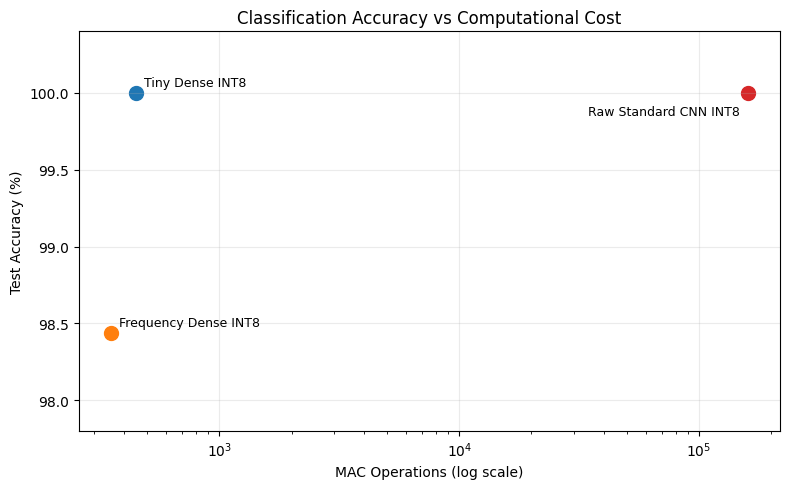

In [ ]:
# ============================================================
# FINAL CLEAN FIGURE 1
# Accuracy vs Computational Cost
# ============================================================

fig_df = final_report_df.copy()

label_offsets_acc = {
    "Tiny Dense INT8": (6, 5),
    "Frequency Dense INT8": (6, 5),
    "Raw Depthwise CNN INT8": (6, 7),
    "Raw Standard CNN INT8": (-115, -16)
}

plt.figure(figsize=(8, 5))

for _, row in fig_df.iterrows():

    plt.scatter(
        row["MACs"],
        row["Accuracy (%)"],
        s=100
    )

    plt.annotate(
        row["Model"],
        (
            row["MACs"],
            row["Accuracy (%)"]
        ),
        xytext=label_offsets_acc[row["Model"]],
        textcoords="offset points",
        fontsize=9
    )

plt.xscale("log")

plt.xlabel("MAC Operations (log scale)")
plt.ylabel("Test Accuracy (%)")
plt.title(
    "Classification Accuracy vs Computational Cost"
)

plt.ylim(97.8, 100.4)
plt.grid(alpha=0.25)

plt.tight_layout()

plt.savefig(
    "accuracy_vs_macs_final.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
fig_df = final_report_df.copy()

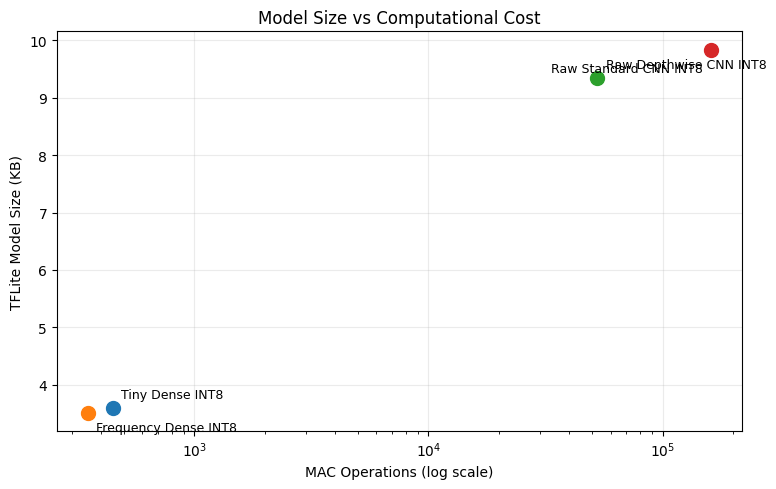

In [ ]:
# ============================================================
# FINAL CLEAN FIGURE 2
# Model Size vs Computational Cost
# ============================================================

fig_df = final_report_df.copy()

label_offsets_size = {
    "Tiny Dense INT8": (6, 7),
    "Frequency Dense INT8": (6, -13),
    "Raw Depthwise CNN INT8": (6, 7),
    "Raw Standard CNN INT8": (-115, -16)
}

plt.figure(figsize=(8, 5))

for _, row in fig_df.iterrows():

    plt.scatter(
        row["MACs"],
        row["TFLite Size (KB)"],
        s=100
    )

    plt.annotate(
        row["Model"],
        (
            row["MACs"],
            row["TFLite Size (KB)"]
        ),
        xytext=label_offsets_size[row["Model"]],
        textcoords="offset points",
        fontsize=9
    )

plt.xscale("log")

plt.xlabel("MAC Operations (log scale)")
plt.ylabel("TFLite Model Size (KB)")
plt.title("Model Size vs Computational Cost")

plt.grid(alpha=0.25)

plt.tight_layout()

plt.savefig(
    "model_size_vs_macs_final.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

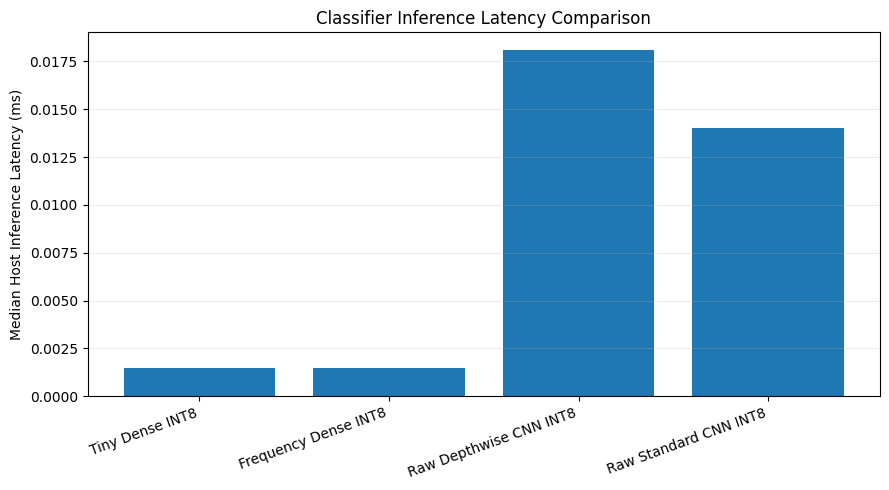

In [ ]:
# ============================================================
# FINAL FIGURE 3
# Host Classifier Inference Latency
# ============================================================

fig_df = final_report_df.copy()

plt.figure(figsize=(9, 5))

plt.bar(
    fig_df["Model"],
    fig_df["Host Latency (ms)"]
)

plt.ylabel(
    "Median Host Inference Latency (ms)"
)

plt.title(
    "Classifier Inference Latency Comparison"
)

plt.xticks(
    rotation=20,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    "host_latency_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# ============================================================
# TRAIN RMS-ONLY OPTIMIZED DENSE MODEL
# ============================================================

mode = "rms"

print("\n" + "=" * 60)
print("Training OPTIMIZED RMS model")
print("=" * 60)

data = prepared_data[mode]

tf.keras.utils.set_random_seed(SEED)

rms_model = build_optimized_dense_model(
    mode,
    num_classes=len(class_names)
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

rms_history = rms_model.fit(
    data["X_train"],
    data["y_train"],

    validation_data=(
        data["X_val"],
        data["y_val"]
    ),

    epochs=150,
    batch_size=16,
    shuffle=True,

    callbacks=[
        early_stop
    ],

    verbose=0
)

rms_test_loss, rms_test_accuracy = (
    rms_model.evaluate(
        data["X_test"],
        data["y_test"],
        verbose=0
    )
)

print(
    f"Input features: "
    f"{data['X_train'].shape[1]}"
)

print(
    f"Parameters:     "
    f"{rms_model.count_params():,}"
)

print(
    f"Epochs:         "
    f"{len(rms_history.history['loss'])}"
)

print(
    f"Test loss:      "
    f"{rms_test_loss:.4f}"
)

print(
    f"Test accuracy:  "
    f"{rms_test_accuracy:.4f}"
)


Training OPTIMIZED RMS model
Input features: 6
Parameters:     112
Epochs:         150
Test loss:      0.4230
Test accuracy:  0.7500


In [ ]:
# ============================================================
# EVALUATE RMS-ONLY MODEL
# ============================================================

rms_prob = rms_model.predict(
    prepared_data["rms"]["X_test"],
    verbose=0
)

rms_pred = np.argmax(
    rms_prob,
    axis=1
)

rms_f1 = f1_score(
    prepared_data["rms"]["y_test"],
    rms_pred,
    average="macro"
)

rms_cm = confusion_matrix(
    prepared_data["rms"]["y_test"],
    rms_pred
)

print("RMS-ONLY RESULTS")
print("=" * 50)

print(
    f"Accuracy: {rms_test_accuracy:.4f}"
)

print(
    f"Macro F1: {rms_f1:.4f}"
)

print("\nConfusion Matrix:")
print(rms_cm)

print("\nClassification Report:")

print(
    classification_report(
        prepared_data["rms"]["y_test"],
        rms_pred,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

RMS-ONLY RESULTS
Accuracy: 0.7500
Macro F1: 0.6667

Confusion Matrix:
[[16  0  0  0]
 [ 0 16  0  0]
 [ 0  0 16  0]
 [16  0  0  0]]

Classification Report:
              precision    recall  f1-score   support

      circle     0.5000    1.0000    0.6667        16
  left_right     1.0000    1.0000    1.0000        16
        rest     1.0000    1.0000    1.0000        16
     up_down     0.0000    0.0000    0.0000        16

    accuracy                         0.7500        64
   macro avg     0.6250    0.7500    0.6667        64
weighted avg     0.6250    0.7500    0.6667        64



In [ ]:
# ============================================================
# TRAIN FFT-BASED DENSE MODEL
# ============================================================

mode = "fft"

print("\n" + "=" * 60)
print("Training FFT-BASED DENSE model")
print("=" * 60)

data = prepared_data[mode]

# Reproducibility
tf.keras.utils.set_random_seed(SEED)

fft_model = build_optimized_dense_model(
    mode,
    num_classes=len(class_names)
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

fft_history = fft_model.fit(
    data["X_train"],
    data["y_train"],

    validation_data=(
        data["X_val"],
        data["y_val"]
    ),

    epochs=150,
    batch_size=16,
    shuffle=True,

    callbacks=[
        early_stop
    ],

    verbose=0
)

fft_test_loss, fft_test_accuracy = fft_model.evaluate(
    data["X_test"],
    data["y_test"],
    verbose=0
)

print(
    f"Input features: "
    f"{data['X_train'].shape[1]}"
)

print(
    f"Parameters:     "
    f"{fft_model.count_params():,}"
)

print(
    f"Epochs:         "
    f"{len(fft_history.history['loss'])}"
)

print(
    f"Test loss:      "
    f"{fft_test_loss:.4f}"
)

print(
    f"Test accuracy:  "
    f"{fft_test_accuracy:.4f}"
)


Training FFT-BASED DENSE model
Input features: 48
Parameters:     3,628
Epochs:         150
Test loss:      0.0004
Test accuracy:  1.0000


In [ ]:
# ============================================================
# EVALUATE FFT-BASED DENSE MODEL
# ============================================================

fft_prob = fft_model.predict(
    prepared_data["fft"]["X_test"],
    verbose=0
)

fft_pred = np.argmax(
    fft_prob,
    axis=1
)

fft_f1 = f1_score(
    prepared_data["fft"]["y_test"],
    fft_pred,
    average="macro"
)

fft_cm = confusion_matrix(
    prepared_data["fft"]["y_test"],
    fft_pred
)

print("FFT-BASED RESULTS")
print("=" * 50)

print(
    f"Accuracy: {fft_test_accuracy:.4f}"
)

print(
    f"Macro F1: {fft_f1:.4f}"
)

print("\nConfusion Matrix:")
print(fft_cm)

print("\nClassification Report:")

print(
    classification_report(
        prepared_data["fft"]["y_test"],
        fft_pred,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

FFT-BASED RESULTS
Accuracy: 1.0000
Macro F1: 1.0000

Confusion Matrix:
[[16  0  0  0]
 [ 0 16  0  0]
 [ 0  0 16  0]
 [ 0  0  0 16]]

Classification Report:
              precision    recall  f1-score   support

      circle     1.0000    1.0000    1.0000        16
  left_right     1.0000    1.0000    1.0000        16
        rest     1.0000    1.0000    1.0000        16
     up_down     1.0000    1.0000    1.0000        16

    accuracy                         1.0000        64
   macro avg     1.0000    1.0000    1.0000        64
weighted avg     1.0000    1.0000    1.0000        64



In [ ]:
# ============================================================
# RMS + FFT FEATURES — BLOCKED SPLIT
# ============================================================

def extract_blocked_feature_matrix(
    windows,
    mode
):
    return np.asarray(
        [
            extract_features_configurable(
                window,
                mode=mode,
                fs=100
            )
            for window in windows
        ],
        dtype=np.float32
    )


blocked_feature_data = {}

for mode in ["rms", "fft"]:

    X_train_features = extract_blocked_feature_matrix(
        X_block_train,
        mode
    )

    X_val_features = extract_blocked_feature_matrix(
        X_block_val,
        mode
    )

    X_test_features = extract_blocked_feature_matrix(
        X_block_test,
        mode
    )

    blocked_feature_data[mode] = {
        "X_train": X_train_features,
        "X_val": X_val_features,
        "X_test": X_test_features
    }

    print("\n" + mode.upper())
    print("=" * 40)

    print(
        "Train:",
        X_train_features.shape
    )

    print(
        "Val:  ",
        X_val_features.shape
    )

    print(
        "Test: ",
        X_test_features.shape
    )


RMS
Train: (192, 6)
Val:   (64, 6)
Test:  (64, 6)

FFT
Train: (192, 48)
Val:   (64, 48)
Test:  (64, 48)


In [ ]:
# ============================================================
# SCALE RMS + FFT FEATURES — BLOCKED SPLIT
# ============================================================

blocked_feature_scalers = {}

for mode in ["rms", "fft"]:

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(
        blocked_feature_data[mode]["X_train"]
    )

    X_val_scaled = scaler.transform(
        blocked_feature_data[mode]["X_val"]
    )

    X_test_scaled = scaler.transform(
        blocked_feature_data[mode]["X_test"]
    )

    blocked_feature_scalers[mode] = scaler

    blocked_feature_data[mode][
        "X_train_scaled"
    ] = X_train_scaled.astype(np.float32)

    blocked_feature_data[mode][
        "X_val_scaled"
    ] = X_val_scaled.astype(np.float32)

    blocked_feature_data[mode][
        "X_test_scaled"
    ] = X_test_scaled.astype(np.float32)

    print("\n" + mode.upper())
    print("=" * 40)

    print(
        "Training mean:",
        np.round(
            X_train_scaled.mean(axis=0),
            4
        )
    )

    print(
        "Training std:",
        np.round(
            X_train_scaled.std(axis=0),
            4
        )
    )


RMS
Training mean: [ 0. -0.  0.  0.  0. -0.]
Training std: [1. 1. 1. 1. 1. 1.]

FFT
Training mean: [-0. -0. -0.  0.  0. -0. -0.  0.  0. -0. -0. -0. -0. -0.  0.  0.  0. -0.
 -0.  0. -0. -0. -0. -0. -0. -0.  0.  0. -0.  0. -0. -0.  0. -0. -0. -0.
 -0. -0.  0. -0. -0. -0. -0. -0.  0.  0.  0.  0.]
Training std: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [ ]:
# ============================================================
# TRAIN + EVALUATE RMS / FFT — BLOCKED SPLIT
# ============================================================

from sklearn.metrics import (
    f1_score,
    confusion_matrix,
    classification_report
)

blocked_models = {}
blocked_histories = {}
blocked_results = {}

for mode in ["rms", "fft"]:

    print("\n" + "=" * 60)
    print(f"{mode.upper()} DENSE — BLOCKED SPLIT")
    print("=" * 60)

    data = blocked_feature_data[mode]

    # --------------------------------------------------------
    # Reproducibility
    # --------------------------------------------------------

    tf.keras.utils.set_random_seed(SEED)

    model = build_optimized_dense_model(
        mode,
        num_classes=len(class_names)
    )

    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True
    )

    # --------------------------------------------------------
    # Training
    # --------------------------------------------------------

    history = model.fit(
        data["X_train_scaled"],
        y_block_train,

        validation_data=(
            data["X_val_scaled"],
            y_block_val
        ),

        epochs=150,
        batch_size=16,
        shuffle=True,

        callbacks=[
            early_stop
        ],

        verbose=0
    )

    # --------------------------------------------------------
    # Test evaluation
    # --------------------------------------------------------

    test_loss, test_accuracy = model.evaluate(
        data["X_test_scaled"],
        y_block_test,
        verbose=0
    )

    y_prob = model.predict(
        data["X_test_scaled"],
        verbose=0
    )

    y_pred = np.argmax(
        y_prob,
        axis=1
    )

    macro_f1 = f1_score(
        y_block_test,
        y_pred,
        average="macro"
    )

    cm = confusion_matrix(
        y_block_test,
        y_pred
    )

    # --------------------------------------------------------
    # Store results
    # --------------------------------------------------------

    blocked_models[mode] = model
    blocked_histories[mode] = history

    blocked_results[mode] = {
        "accuracy": float(test_accuracy),
        "macro_f1": float(macro_f1),
        "loss": float(test_loss),
        "epochs": len(
            history.history["loss"]
        ),
        "predictions": y_pred
    }

    # --------------------------------------------------------
    # Print
    # --------------------------------------------------------

    print(
        f"Features:   "
        f"{data['X_train_scaled'].shape[1]}"
    )

    print(
        f"Parameters: "
        f"{model.count_params():,}"
    )

    print(
        f"Epochs:     "
        f"{len(history.history['loss'])}"
    )

    print(
        f"Test loss:  "
        f"{test_loss:.4f}"
    )

    print(
        f"Accuracy:   "
        f"{test_accuracy:.4f}"
    )

    print(
        f"Macro F1:   "
        f"{macro_f1:.4f}"
    )

    print("\nConfusion Matrix:")
    print(cm)

    print("\nClassification Report:")

    print(
        classification_report(
            y_block_test,
            y_pred,
            target_names=class_names,
            digits=4,
            zero_division=0
        )
    )


RMS DENSE — BLOCKED SPLIT
Features:   6
Parameters: 112
Epochs:     150
Test loss:  0.3952
Accuracy:   0.7500
Macro F1:   0.6667

Confusion Matrix:
[[ 0  0  0 16]
 [ 0 16  0  0]
 [ 0  0 16  0]
 [ 0  0  0 16]]

Classification Report:
              precision    recall  f1-score   support

      circle     0.0000    0.0000    0.0000        16
  left_right     1.0000    1.0000    1.0000        16
        rest     1.0000    1.0000    1.0000        16
     up_down     0.5000    1.0000    0.6667        16

    accuracy                         0.7500        64
   macro avg     0.6250    0.7500    0.6667        64
weighted avg     0.6250    0.7500    0.6667        64


FFT DENSE — BLOCKED SPLIT
Features:   48
Parameters: 3,628
Epochs:     150
Test loss:  0.0012
Accuracy:   1.0000
Macro F1:   1.0000

Confusion Matrix:
[[16  0  0  0]
 [ 0 16  0  0]
 [ 0  0 16  0]
 [ 0  0  0 16]]

Classification Report:
              precision    recall  f1-score   support

      circle     1.0000    1.0000    1.

In [ ]:
# ============================================================
# FINAL ROBUSTNESS SUMMARY
# Random Split vs Blocked Split
# ============================================================

robustness_results = [
    {
        "model": "1-NN Raw",
        "random_accuracy": knn_accuracy,
        "blocked_accuracy": knn_block_accuracy,
        "random_macro_f1": knn_f1,
        "blocked_macro_f1": knn_block_f1
    },

    {
        "model": "RMS Dense",
        "random_accuracy": rms_test_accuracy,
        "blocked_accuracy":
            blocked_results["rms"]["accuracy"],
        "random_macro_f1": rms_f1,
        "blocked_macro_f1":
            blocked_results["rms"]["macro_f1"]
    },

    {
        "model": "FFT Dense",
        "random_accuracy": fft_test_accuracy,
        "blocked_accuracy":
            blocked_results["fft"]["accuracy"],
        "random_macro_f1": fft_f1,
        "blocked_macro_f1":
            blocked_results["fft"]["macro_f1"]
    },

    {
        "model": "Tiny Dense",
        "random_accuracy":
            final_benchmark_df.loc[
                final_benchmark_df["model"] == "tiny",
                "float_accuracy"
            ].iloc[0],

        "blocked_accuracy":
            tiny_block_accuracy,

        "random_macro_f1":
            final_benchmark_df.loc[
                final_benchmark_df["model"] == "tiny",
                "float_macro_f1"
            ].iloc[0],

        "blocked_macro_f1":
            tiny_block_f1
    }
]

robustness_df = pd.DataFrame(
    robustness_results
)

# Accuracy change:
# positive = performance decreased on blocked split
robustness_df["accuracy_drop"] = (
    robustness_df["random_accuracy"]
    - robustness_df["blocked_accuracy"]
)

robustness_df["macro_f1_drop"] = (
    robustness_df["random_macro_f1"]
    - robustness_df["blocked_macro_f1"]
)

display(
    robustness_df.round(4)
)

,model,random_accuracy,blocked_accuracy,random_macro_f1,blocked_macro_f1,accuracy_drop,macro_f1_drop
0,1-NN Raw,1.00,1.00,1.0000,1.0000,0.0,0.0
1,RMS Dense,0.75,0.75,0.6667,0.6667,0.0,0.0
2,FFT Dense,1.00,1.00,1.0000,1.0000,0.0,0.0
3,Tiny Dense,1.00,1.00,1.0000,1.0000,0.0,0.0


In [ ]:
# ============================================================
# FINAL IDEA 3 — FEATURE ENGINEERING COMPARISON
# ============================================================

idea3_results = []

# ------------------------------------------------------------
# RMS-only
# ------------------------------------------------------------

idea3_results.append({
    "Representation": "RMS",
    "Input Features": 6,
    "Architecture": "Dense",
    "Parameters": rms_model.count_params(),
    "Accuracy (%)": rms_test_accuracy * 100,
    "Macro F1": rms_f1
})


# ------------------------------------------------------------
# FFT magnitude
# ------------------------------------------------------------

idea3_results.append({
    "Representation": "FFT",
    "Input Features": 48,
    "Architecture": "Dense",
    "Parameters": fft_model.count_params(),
    "Accuracy (%)": fft_test_accuracy * 100,
    "Macro F1": fft_f1
})


# ------------------------------------------------------------
# Existing engineered-feature models
# ------------------------------------------------------------

for mode in [
    "frequency",
    "tiny",
    "time",
    "combined"
]:

    row = final_benchmark_df[
        final_benchmark_df["model"] == mode
    ].iloc[0]

    idea3_results.append({
        "Representation": mode.capitalize(),
        "Input Features": int(row["features"]),
        "Architecture": "Dense",
        "Parameters": int(row["parameters"]),
        "Accuracy (%)": row["float_accuracy"] * 100,
        "Macro F1": row["float_macro_f1"]
    })


# ------------------------------------------------------------
# Raw signal — Standard CNN
# ------------------------------------------------------------

idea3_results.append({
    "Representation": "Raw Signal",
    "Input Features": 128 * 6,
    "Architecture": "Standard CNN",
    "Parameters": raw_cnn.count_params(),
    "Accuracy (%)": raw_cnn_test_accuracy * 100,
    "Macro F1": raw_cnn_f1
})


# ------------------------------------------------------------
# Raw signal — Depthwise CNN
# ------------------------------------------------------------

idea3_results.append({
    "Representation": "Raw Signal",
    "Input Features": 128 * 6,
    "Architecture": "Depthwise CNN",
    "Parameters": raw_depthwise_cnn.count_params(),
    "Accuracy (%)": raw_depthwise_test_accuracy * 100,
    "Macro F1": raw_depthwise_f1
})


# ------------------------------------------------------------
# Build final table
# ------------------------------------------------------------

idea3_df = pd.DataFrame(
    idea3_results
)

idea3_df = idea3_df.sort_values(
    by=[
        "Accuracy (%)",
        "Parameters"
    ],
    ascending=[
        False,
        True
    ]
).reset_index(drop=True)

idea3_df = idea3_df.round({
    "Accuracy (%)": 2,
    "Macro F1": 4
})

display(idea3_df)

,Representation,Input Features,Architecture,Parameters,Accuracy (%),Macro F1
0,Tiny,18,Dense,476,100.00,1.0000
1,Raw Signal,768,Standard CNN,2660,100.00,1.0000
2,Time,30,Dense,2764,100.00,1.0000
3,FFT,48,Dense,3628,100.00,1.0000
4,Combined,42,Dense,4964,100.00,1.0000
5,Frequency,12,Dense,380,98.44,0.9844
6,RMS,6,Dense,112,75.00,0.6667
7,Raw Signal,768,Depthwise CNN,1330,12.50,0.1111


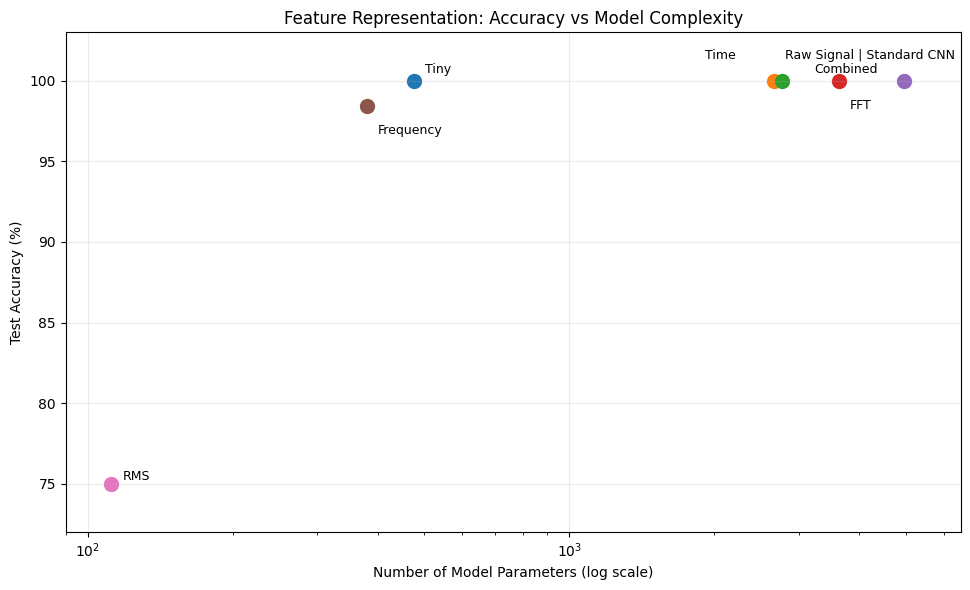

In [ ]:
# ============================================================
# FINAL IDEA 3 FIGURE — REPORT VERSION
# Accuracy vs Model Parameters
# ============================================================

plt.figure(figsize=(10, 6))

label_positions = {
    "RMS": (8, 5),
    "Frequency": (8, -18),
    "Tiny": (8, 8),

    "Raw Signal | Depthwise CNN": (8, -18),
    "Raw Signal | Standard CNN": (8, 18),

    "Time": (-55, 18),
    "FFT": (8, -18),
    "Combined": (-65, 8)
}

for _, row in idea3_df.iterrows():

    if row["Representation"] == "Raw Signal":
        label = (
            f"Raw Signal | "
            f"{row['Architecture']}"
        )
    else:
        label = row["Representation"]

    plt.scatter(
        row["Parameters"],
        row["Accuracy (%)"],
        s=100
    )

    plt.annotate(
        label,
        (
            row["Parameters"],
            row["Accuracy (%)"]
        ),
        xytext=label_positions[label],
        textcoords="offset points",
        fontsize=9,
        va="center"
    )


plt.xscale("log")

plt.xlabel(
    "Number of Model Parameters (log scale)"
)

plt.ylabel(
    "Test Accuracy (%)"
)

plt.title(
    "Feature Representation: Accuracy vs Model Complexity"
)

# Give annotations more vertical room
plt.ylim(72, 103)

# Give Combined more room on the right
plt.xlim(90, 6500)

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    "idea3_accuracy_vs_parameters_final.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# ============================================================
# SAVE FINAL IDEA 3 RESULTS
# ============================================================

idea3_df.to_csv(
    "idea3_feature_engineering_results.csv",
    index=False
)

robustness_df.to_csv(
    "idea3_robustness_results.csv",
    index=False
)

print("Saved:")
print("idea3_feature_engineering_results.csv")
print("idea3_robustness_results.csv")
print("idea3_accuracy_vs_parameters_final.png")

Saved:
idea3_feature_engineering_results.csv
idea3_robustness_results.csv
idea3_accuracy_vs_parameters_final.png


In [ ]:
# ============================================================
# EXPORT TINY INT8 MODEL AS C HEADER
# ============================================================

model_bytes = tflite_int8_models["tiny"]["model"]

with open("tiny_model.h", "w") as f:

    f.write("#ifndef TINY_MODEL_H\n")
    f.write("#define TINY_MODEL_H\n\n")

    f.write(
        "const unsigned char tiny_model[] = {\n"
    )

    for i, byte in enumerate(model_bytes):

        if i % 12 == 0:
            f.write("    ")

        f.write(
            f"0x{byte:02x}"
        )

        if i != len(model_bytes) - 1:
            f.write(", ")

        if (i + 1) % 12 == 0:
            f.write("\n")

    f.write("\n};\n\n")

    f.write(
        f"const unsigned int tiny_model_len = "
        f"{len(model_bytes)};\n"
    )

    f.write("\n#endif\n")


print("tiny_model.h created")
print("Model bytes:", len(model_bytes))

tiny_model.h created
Model bytes: 3688


In [ ]:
# ============================================================
# EXPORT TINY STANDARD SCALER AS C HEADER
# ============================================================

tiny_scaler = scalers["tiny"]

num_features = len(
    tiny_scaler.mean_
)

with open("tiny_scaler.h", "w") as f:

    f.write("#ifndef TINY_SCALER_H\n")
    f.write("#define TINY_SCALER_H\n\n")

    f.write(
        f"const float tiny_mean[{num_features}] = {{\n"
    )

    for i, value in enumerate(
        tiny_scaler.mean_
    ):

        f.write(
            f"    {value:.10e}f"
        )

        if i < num_features - 1:
            f.write(",")

        f.write("\n")

    f.write("};\n\n")

    f.write(
        f"const float tiny_scale[{num_features}] = {{\n"
    )

    for i, value in enumerate(
        tiny_scaler.scale_
    ):

        f.write(
            f"    {value:.10e}f"
        )

        if i < num_features - 1:
            f.write(",")

        f.write("\n")

    f.write("};\n\n")

    f.write("#endif\n")


print("tiny_scaler.h created")
print(
    "Number of features:",
    num_features
)

tiny_scaler.h created
Number of features: 18


In [ ]:
# ============================================================
# EXPORT RAW DEPTHWISE CNN INT8 FOR ARDUINO
# ============================================================

depthwise_int8_bytes = depthwise_int8_tflite

print(
    "Depthwise INT8 TFLite size:",
    len(depthwise_int8_bytes),
    "bytes"
)

with open(
    "depthwise_model.h",
    "w"
) as f:

    f.write(
        "#ifndef DEPTHWISE_MODEL_H\n"
    )

    f.write(
        "#define DEPTHWISE_MODEL_H\n\n"
    )

    f.write(
        "#include <stdint.h>\n\n"
    )

    f.write(
        "const unsigned char "
        "depthwise_model[] = {\n"
    )

    for i, byte in enumerate(
        depthwise_int8_bytes
    ):

        if i % 12 == 0:
            f.write("    ")

        f.write(
            f"0x{byte:02x}"
        )

        if i != len(
            depthwise_int8_bytes
        ) - 1:
            f.write(", ")

        if (i + 1) % 12 == 0:
            f.write("\n")

    f.write(
        "\n};\n\n"
    )

    f.write(
        "const unsigned int "
        "depthwise_model_len = "
        f"{len(depthwise_int8_bytes)};\n\n"
    )

    f.write(
        "#endif\n"
    )

print(
    "depthwise_model.h created"
)

print(
    "Model bytes:",
    len(depthwise_int8_bytes)
)

Depthwise INT8 TFLite size: 9576 bytes
depthwise_model.h created
Model bytes: 9576


In [ ]:
# ============================================================
# INSPECT RAW DEPTHWISE CNN INT8 MODEL
# ============================================================

import tensorflow as tf
import numpy as np

depthwise_interpreter = tf.lite.Interpreter(
    model_content=depthwise_int8_tflite
)

depthwise_interpreter.allocate_tensors()

input_details = depthwise_interpreter.get_input_details()
output_details = depthwise_interpreter.get_output_details()

print("=" * 60)
print("RAW DEPTHWISE CNN INT8 — TENSOR DETAILS")
print("=" * 60)

print("\nINPUT")
print("-" * 60)

print(
    "Shape:",
    input_details[0]["shape"]
)

print(
    "dtype:",
    input_details[0]["dtype"]
)

print(
    "Quantization:",
    input_details[0]["quantization"]
)

print(
    "Scale:",
    input_details[0]["quantization"][0]
)

print(
    "Zero point:",
    input_details[0]["quantization"][1]
)

print("\nOUTPUT")
print("-" * 60)

print(
    "Shape:",
    output_details[0]["shape"]
)

print(
    "dtype:",
    output_details[0]["dtype"]
)

print(
    "Quantization:",
    output_details[0]["quantization"]
)

print(
    "Scale:",
    output_details[0]["quantization"][0]
)

print(
    "Zero point:",
    output_details[0]["quantization"][1]
)

print("\nMODEL")
print("-" * 60)

print(
    "Model bytes:",
    len(depthwise_int8_tflite)
)

print(
    "Input elements:",
    np.prod(input_details[0]["shape"])
)

print(
    "Output elements:",
    np.prod(output_details[0]["shape"])
)

RAW DEPTHWISE CNN INT8 — TENSOR DETAILS

INPUT
------------------------------------------------------------
Shape: [  1 128   6]
dtype: <class 'numpy.int8'>
Quantization: (0.04553470015525818, 13)
Scale: 0.04553470015525818
Zero point: 13

OUTPUT
------------------------------------------------------------
Shape: [1 4]
dtype: <class 'numpy.int8'>
Quantization: (0.00390625, -128)
Scale: 0.00390625
Zero point: -128

MODEL
------------------------------------------------------------
Model bytes: 9576
Input elements: 768
Output elements: 4


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [ ]:
# ============================================================
# LIST TFLITE OPERATORS — RAW DEPTHWISE CNN INT8
# ============================================================

import tensorflow as tf

interpreter = tf.lite.Interpreter(
    model_content=depthwise_int8_tflite
)

interpreter.allocate_tensors()

ops = interpreter._get_ops_details()

print("=" * 60)
print("RAW DEPTHWISE CNN INT8 — OPERATORS")
print("=" * 60)

unique_ops = []

for i, op in enumerate(ops):

    op_name = op["op_name"]

    print(
        f"{i:2d} -> {op_name}"
    )

    if op_name not in unique_ops:
        unique_ops.append(op_name)


print("\n" + "=" * 60)
print("UNIQUE OPERATORS")
print("=" * 60)

for op_name in unique_ops:
    print(op_name)

print(
    "\nTotal operator nodes:",
    len(ops)
)

print(
    "Unique operator types:",
    len(unique_ops)
)

RAW DEPTHWISE CNN INT8 — OPERATORS
 0 -> EXPAND_DIMS
 1 -> DEPTHWISE_CONV_2D
 2 -> CONV_2D
 3 -> RESHAPE
 4 -> EXPAND_DIMS
 5 -> MAX_POOL_2D
 6 -> RESHAPE
 7 -> EXPAND_DIMS
 8 -> DEPTHWISE_CONV_2D
 9 -> CONV_2D
10 -> RESHAPE
11 -> MEAN
12 -> FULLY_CONNECTED
13 -> FULLY_CONNECTED
14 -> SOFTMAX
15 -> DELEGATE
16 -> DELEGATE
17 -> DELEGATE

UNIQUE OPERATORS
EXPAND_DIMS
DEPTHWISE_CONV_2D
CONV_2D
RESHAPE
MAX_POOL_2D
MEAN
FULLY_CONNECTED
SOFTMAX
DELEGATE

Total operator nodes: 18
Unique operator types: 9


In [ ]:
# ============================================================
# EXPORT RAW-SIGNAL TRAINING NORMALIZATION FOR ARDUINO
# ============================================================

import numpy as np

raw_mean_deploy = X_raw_train.mean(
    axis=(0, 1)
).astype(np.float32)

raw_std_deploy = X_raw_train.std(
    axis=(0, 1)
).astype(np.float32)

raw_std_deploy = np.where(
    raw_std_deploy < 1e-8,
    1.0,
    raw_std_deploy
).astype(np.float32)

print("RAW MEAN:")
print(raw_mean_deploy)

print("\nRAW STD:")
print(raw_std_deploy)

with open("raw_scaler.h", "w") as f:

    f.write("#ifndef RAW_SCALER_H\n")
    f.write("#define RAW_SCALER_H\n\n")

    f.write("const float raw_mean[6] = {\n")

    for i, value in enumerate(raw_mean_deploy):
        comma = "," if i < 5 else ""
        f.write(
            f"    {value:.10e}f{comma}\n"
        )

    f.write("};\n\n")

    f.write("const float raw_std[6] = {\n")

    for i, value in enumerate(raw_std_deploy):
        comma = "," if i < 5 else ""
        f.write(
            f"    {value:.10e}f{comma}\n"
        )

    f.write("};\n\n")
    f.write("#endif\n")

print("\nSaved: raw_scaler.h")

RAW MEAN:
[-0.00392063 -0.09010717 -0.13027927 -1.5915517   0.14677145 -0.04352759]

RAW STD:
[ 0.25857764  0.60423815  0.75048846 18.721096   17.978252   56.139603  ]

Saved: raw_scaler.h
